# Reliability- and Uncertainty-Aware Multimodal Learning for Disaster Understanding
## Part 1 of 2 — Data, Model Definition, and Training

**This is Part 1 of a two-notebook split of the original single research notebook**
(`reliabilty-aware-disaster-management-notebook_with_results.ipynb`). The split was made by
inspecting cell-to-cell variable dependencies, not by cutting at an arbitrary cell number.

**Boundary rule used:** Part 1 contains everything through the end of **Section 13 (Model
Training)** — i.e. every cell whose output (a trained checkpoint, the processed dataframes,
the label encoders, the training history) is a genuine *input* to Section 14 onward. Part 2
(`Disaster_Research_Part2.ipynb`) starts at **Section 14 (Calibration and TTA)** and re-derives
everything else — including the model architecture classes and the DataLoaders — from files
saved at the end of this notebook, rather than from in-memory variables.

**Architecture, data pipeline, training loop, hyperparameters, and loss functions below are
copied unchanged from the original notebook.** Nothing in Sections 1–13 was rewritten. The only
additions in this notebook are: this note, the Section-2 map below, and one new cell at the very
end ("Save Artifacts for Part 2") that persists what Part 2 needs to plain files.

### Environment constraint (read before running)
This editing/splitting pass was carried out **without GPU access, without `torch`/`transformers`
installed, and without a copy of the CrisisMMD dataset** in the environment used to reorganize
these cells — the same constraint the original notebook already disclosed about its own most
recent edits. Concretely, this means:
- The cell-to-cell **dependency analysis** below (which variable is produced by which cell, and
  consumed by which later cell) was done by static inspection of the actual code, not by running it.
- **No cell in this notebook has been executed as part of creating this split.** Any results shown
  if you re-open a *previously executed* copy of these cells are from a genuine prior run (as the
  original notebook already stated), not something regenerated here.
- You must run this notebook top-to-bottom yourself, with a GPU and the CrisisMMD dataset attached,
  to produce a real checkpoint and real artifacts for Part 2. Do not assume the plots/metrics you
  see are current until you've done that.


## Section Map

This notebook's cells are numbered 1–26 below in **execution order**, which is the order
they must run in for variables to be defined correctly. This differs slightly from a purely
logical journal outline in one place: **Section 14 (Calibration and Test-Time Augmentation)
appears before Section 16 (Main Test Results)** and before Section 21 (Ablation Study),
because the ablation study's post-hoc technique table (Section 21) reuses the calibration
bias tensor computed in Section 14 (`use_calib=True` reads `CALIB_BIAS`, which only exists
after Section 14 runs). Reordering these cells to a strict "results, then ablation, then
calibration" sequence would break that dependency and was not done, per the requirement to
keep the notebook runnable top-to-bottom. All other sections follow the requested outline.

| # | Section |
|---|---|
| 1 | Experimental Configuration and Reproducibility |
| 2 | CrisisMMD Dataset |
| 3 | Data Preprocessing |
| 4 | Model Components: E-REM, UASG, and UG-CMA (overview) |
| 5 | Text Encoder: DeBERTa-v3 |
| 6 | Image Encoder: CLIP ViT-B/32 |
| 7 | Evidence-based Reliability and Uncertainty Module (E-REM) |
| 8 | Uncertainty-Aware Soft Gating (UASG) |
| 9 | Contrastive Alignment with InfoNCE |
| 10 | Uncertainty-Guided Cross-Modal Attention (UG-CMA) |
| 11 | Shared Multimodal Representation and Multi-Task Prediction Heads |
| 12 | Multi-Task Training Objective |
| 13 | Model Training |
| 14 | Calibration and Test-Time Augmentation |
| 15 | Training and Validation Curves |
| 16 | Main Test Results |
| 17 | Confusion Matrices |
| 18 | Uncertainty Analysis |
| 19 | Explainability with Grad-CAM |
| 20 | Representation Visualization (t-SNE) |
| 21 | Ablation Study |
| 22 | Per-Class and Per-Task Performance |
| 23 | Statistical Significance |
| 24 | Single-Sample Inference |
| 25 | Final Experimental Summary |
| 26 | Experimental Reproduction Status |


### Part 1 contents (original Sections 1–13, unmodified)
| # | Section |
|---|---|
| 1 | Experimental Configuration and Reproducibility |
| 2 | CrisisMMD Dataset |
| 3 | Data Preprocessing |
| 4 | Model Components: E-REM, UASG, and UG-CMA (overview) |
| 5 | Text Encoder: DeBERTa-v3 |
| 6 | Image Encoder: CLIP ViT-B/32 |
| 7 | Evidence-based Reliability and Uncertainty Module (E-REM) |
| 8 | Uncertainty-Aware Soft Gating (UASG) |
| 9 | Contrastive Alignment with InfoNCE |
| 10 | Uncertainty-Guided Cross-Modal Attention (UG-CMA) |
| 11 | Shared Multimodal Representation and Multi-Task Prediction Heads |
| 12 | Multi-Task Training Objective |
| 13 | Model Training |

Sections 14–26 (calibration, test results, confusion matrices, uncertainty analysis, Grad-CAM,
t-SNE, ablation, per-class performance, statistical significance, single-sample inference, final
summary) live in **`Disaster_Research_Part2.ipynb`**, which loads its inputs from the artifacts
this notebook saves in its last cell.


## 1. Experimental Configuration and Reproducibility

Installs `transformers`, `open_clip_torch`, and `grad-cam` from PyPI. **Prerequisite:** enable Internet access in the Kaggle sidebar before running.

In [1]:
import subprocess, sys

def pip_install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

pip_install('sentencepiece')
pip_install('protobuf')
pip_install('transformers==4.40.1')
pip_install('open_clip_torch')
pip_install('grad-cam')

print('✅ All packages installed successfully.')

import gc
gc.collect()

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.0/138.0 kB 686.3 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 12.1 MB/s eta 0:00:00


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.4.1 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.40.1 which is incompatible.


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 50.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 2.8 MB/s eta 0:00:00
✅ All packages installed successfully.


4

### 1.1 Library Imports

Organizes all imports into logical blocks: Core/OS, Data Science, Visualization, Deep Learning, Pre-trained Models (DeBERTa-v3 + CLIP), Image Processing, Evaluation, and Explainability (Grad-CAM).

In [2]:
import os, sys, warnings, logging, random, json, time, copy, math
from pathlib import Path
from datetime import datetime
warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.ERROR)

import numpy  as np
import pandas as pd
from scipy.stats import entropy as scipy_entropy

import matplotlib
import matplotlib.pyplot  as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
matplotlib.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
})

import torch
import torch.nn            as nn
import torch.nn.functional as F
import torch.optim         as optim
from torch.utils.data      import Dataset, DataLoader
from torch.cuda.amp        import GradScaler, autocast

from transformers import (
    AutoTokenizer, AutoModel,
    get_cosine_schedule_with_warmup,
)
import open_clip

from PIL                import Image
import cv2
from torchvision        import transforms

from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, accuracy_score, precision_recall_fscore_support,
)
from sklearn.preprocessing import LabelEncoder

def free_memory():
    """Release Python + CUDA memory. Call after large intermediate objects
    (dataframes, batches, hooks) are no longer needed."""
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

print('✅ All libraries imported | seed_everything() defined -- call it explicitly per run/seed, no fixed lock here')

import gc
gc.collect()
try:
    import torch
    torch.cuda.empty_cache()
except Exception:
    pass

✅ All libraries imported | seed_everything() defined -- call it explicitly per run/seed, no fixed lock here


### 1.2 Device Configuration (CPU/GPU-safe)

Detects the available accelerator (CUDA / MPS / CPU) and fixes the global random seed for reproducibility.

In [3]:
if torch.cuda.is_available():
    DEVICE     = torch.device('cuda')
    N_GPUS     = torch.cuda.device_count()
    GPU_NAMES  = [torch.cuda.get_device_name(i) for i in range(N_GPUS)]
    VRAM_GB    = [torch.cuda.get_device_properties(i).total_memory / 1e9 for i in range(N_GPUS)]
else:
    DEVICE    = torch.device('cpu')
    N_GPUS    = 0
    GPU_NAMES = []
    VRAM_GB   = []

USE_AMP = N_GPUS > 0

print('=' * 60)
print('  🖥️  Hardware Configuration')
print('=' * 60)
print(f'  PyTorch Version  : {torch.__version__}')
print(f'  CUDA Available   : {torch.cuda.is_available()}')
print(f'  Device           : {DEVICE}')
print(f'  Number of GPUs   : {N_GPUS}')
for i, (name, vram) in enumerate(zip(GPU_NAMES, VRAM_GB)):
    print(f'    GPU {i}: {name}  ({vram:.1f} GB VRAM)')
print(f'  Mixed Precision  : {USE_AMP}')
print('=' * 60)
if N_GPUS == 0:
    print('GPU not available. Full model training may be computationally expensive on CPU.')
    print('The notebook remains functionally CPU-safe; no CUDA-only code path is required to run it.')

def gpu_memory_report():
    """Per-GPU allocated / reserved / total memory (GB). No-op message on CPU-only runs.
    Call between large experiments (Grad-CAM, t-SNE, ablation, checkpoint reloads) to check
    headroom on each T4 individually -- with 2xT4, each GPU has its OWN ~15 GB limit; the pair
    is NOT a pooled 32 GB device, and nn.DataParallel still replicates activations per-GPU."""
    if not torch.cuda.is_available():
        print('  [gpu_memory_report] No CUDA device available.')
        return
    print('-' * 60)
    for i in range(torch.cuda.device_count()):
        alloc = torch.cuda.memory_allocated(i) / 1e9
        resv  = torch.cuda.memory_reserved(i)  / 1e9
        total = torch.cuda.get_device_properties(i).total_memory / 1e9
        print(f'  GPU {i} ({torch.cuda.get_device_name(i)}): '
              f'allocated={alloc:5.2f} GB | reserved={resv:5.2f} GB | total={total:5.2f} GB')
    print('-' * 60)

gpu_memory_report()

free_memory()

  🖥️  Hardware Configuration
  PyTorch Version  : 2.10.0+cu128
  CUDA Available   : True
  Device           : cuda
  Number of GPUs   : 2
    GPU 0: Tesla T4  (15.6 GB VRAM)
    GPU 1: Tesla T4  (15.6 GB VRAM)
  Mixed Precision  : True
------------------------------------------------------------
  GPU 0 (Tesla T4): allocated= 0.00 GB | reserved= 0.00 GB | total=15.64 GB
  GPU 1 (Tesla T4): allocated= 0.00 GB | reserved= 0.00 GB | total=15.64 GB
------------------------------------------------------------


### 1.3 Configuration Parameters

Defines `CFG`, the single source of truth for dataset paths, pre-trained checkpoint names (`microsoft/deberta-v3-base`, CLIP **ViT-B/32**), dimensions, training hyperparameters, loss weights, and task label maps.

In [4]:
import os
import gc
from pathlib import Path

def _find_dataset_root():
    env = os.environ.get('CRISISMD_ROOT')
    if env and Path(env).exists():
        return Path(env)

    kaggle_slugs = [
        '/kaggle/input/datasets/seaninggg/crisismmd-multimodal-crisis-dataset',
        '/kaggle/input/datasets/seaninggg/crisismmd-multimodal-crisis-dataset/CrisisMMD_v2.0',
        '/kaggle/input/crisismmd-multimodal-crisis-dataset',
        '/kaggle/input/crisismmdv2',
        '/kaggle/input/crisis-mmd',
    ]
    for s in kaggle_slugs:
        if Path(s).exists():
            return Path(s)

    local_tries = [
        Path('/content/CrisisMMD_v2.0'),
        Path('/content/CrisisMMD'),
        Path('/workspace/CrisisMMD'),
        Path('/data/CrisisMMD'),
        Path.home() / 'datasets' / 'CrisisMMD',
        Path.home() / 'data' / 'CrisisMMD',
        Path('./CrisisMMD_v2.0'),
        Path('./CrisisMMD'),
    ]
    for p in local_tries:
        if p.exists():
            return p

    raise FileNotFoundError(
        '\n' + '=' * 65 + '\n'
        'CrisisMMD dataset NOT FOUND.\n\n'
        'Check the right-hand sidebar under "Data" and ensure the dataset is attached.\n'
        + '=' * 65
    )

def _find_data_dir(root):
    sub = root / 'CrisisMMD_v2.0'
    return sub if sub.exists() else root

def _find_output_dir():
    for candidate in [Path('/kaggle/working'), Path('/content'), Path('./outputs')]:
        if candidate.parent.exists():
            candidate.mkdir(parents=True, exist_ok=True)
            return candidate
    return Path('.')

try:
    _ROOT = _find_dataset_root()
except FileNotFoundError as e:
    print(e)
    _ROOT = Path('.')

_DATA    = _find_data_dir(_ROOT)
_ANN_DIR = _DATA / 'annotations'
_IMG_DIR = _DATA / 'data_image'
_OUT_DIR = _find_output_dir()

class CFG:

    # Master seed for this run's reproducibility (train/dev/test split, model init,
    # dropout, shuffling, TSNE, etc). This notebook is fixed to a single official seed.
    SEED      = 42

    ROOT      = _ROOT
    DATA_DIR  = _DATA
    ANN_DIR   = _ANN_DIR
    IMG_DIR   = _IMG_DIR
    OUT_DIR   = _OUT_DIR

    ALL_TSVS  = [
        f for f in _ANN_DIR.iterdir()
        if f.suffix == '.tsv' and not f.name.startswith('._')
    ] if _ANN_DIR.exists() else []

    ROBERTA_CKPT  = 'microsoft/deberta-v3-base'
    CLIP_MODEL    = 'ViT-B-32'
    CLIP_PRETRAIN = 'openai'

    TEXT_DIM      = 768
    VIS_DIM       = 768
    FUSE_DIM      = 768
    GRAPH_HIDDEN  = 512
    GRAPH_OUT     = 384
    HEAD_DIM      = 256

    BATCH_SIZE    = 32
    EPOCHS        = 45
    LR_ROBERTA    = 1e-5
    LR_CLIP       = 1e-5
    LR_HEAD       = 3e-4
    WEIGHT_DECAY  = 1e-2
    WARMUP_RATIO  = 0.1
    MAX_GRAD_NORM = 1.0
    MAX_LEN       = 128
    IMG_SIZE      = 224
    PATIENCE      = 10

    CKPT_TASKS       = ['human', 'damage']
    CKPT_METRIC_BLEND = 0.5   # NEW: checkpoint-selection criterion blends macro F1 (weight
                              # CKPT_METRIC_BLEND) with weighted F1 (1-CKPT_METRIC_BLEND), so
                              # the saved checkpoint can't win purely via majority classes.
    FOCAL_GAMMA_HUD    = 1.5

    FOCAL_GAMMA_HUMAN  = 2.0   # was 1.5 -- pushed up to down-weight easy majority
                               # (not_humanitarian/rescue_or_response) samples harder,
                               # since affected_people/damage_related sit at ~100-130 support.
    FOCAL_GAMMA_DAMAGE = 1.8   # was 1.2 -- same reasoning for little_or_no_damage (35) /
                               # mild_damage (92).
    USE_SAMPLER      = True

    SOFTEN_CB_WITH_SAMPLER = True

    USE_CLASS_BALANCED_LOSS = True

    CB_BETA                 = 0.999 if SOFTEN_CB_WITH_SAMPLER and USE_SAMPLER else 0.9999
    USE_MANIFOLD_MIXUP      = True
    MIXUP_ALPHA             = 0.2
    MIXUP_PROB              = 0.5
    USE_LOGIT_CALIBRATION   = True
    CALIB_SEARCH_ITERS      = 800   # was 300 -- 3-4 classes/task needs more random-coordinate
                                    # steps to actually cover the bias search space.
    USE_TTA                 = True
    USE_TEXT_CLEANING       = True
    USE_HIERARCHICAL_GATING = True   # legacy POST-HOC rule -- confidence-thresholded, off
                                      # by default per Section 21.2 (do not confuse with
                                      # USE_TASK_GATES below, which is a different mechanism).
    USE_TASK_GATES = True   # NEW: learned, differentiable FiLM-style gates on the human/damage
                            # heads (see Section 11.1). Trained jointly, initialized as an
                            # identity map, so it can only help -- it is NOT the hard post-hoc
                            # override that Section 21.2 found and disabled.
    GATE_HIDDEN = 128
    RUN_GENUINE_ABLATION    = True
    ABLATION_RETRAIN_EPOCHS = 15

    ABLATION_SEEDS          = [SEED]   # single-seed notebook: ablation uses the same official seed

    FREEZE_ENCODER_EPOCHS = 2
    HUMAN_DAMAGE_LABEL_SMOOTHING = 0.08
    USE_NO_DECAY_GROUPS   = True
    LOG_VAR_CLAMP         = (-3.0, 3.0)
    MIXUP_LOSS_BLEND      = 0.3
    GRAD_ACCUM_STEPS      = 2

    EFFECTIVE_SCHEDULE_EPOCHS = 22
    SWA_PER_TASK_TOLERANCE    = 0.01

    LAMBDA_EVENT   = 1.0
    LAMBDA_INFO    = 1.2
    LAMBDA_HUMAN   = 2.0
    LAMBDA_DAMAGE  = 2.0
    LAMBDA_VERIF   = 1.2

    LAMBDA_UNCERT  = 0.3

    FOCAL_GAMMA_VERIF = 1.5
    CB_BETA_VERIF     = 0.99
    VERIF_LABEL_SMOOTHING = 0.05

    EREM_N_PROTOTYPES = 8

    USE_FILM_SE_GATING = True

    USE_SUPCON      = True
    SUPCON_TEMP     = 0.1
    SUPCON_TASK     = 'event_type'
    SUPCON_WEIGHT_INIT = 0.15

    GRADCAM_N_EVAL_SAMPLES = 100
    GRADCAM_METHODS        = ['gradcam', 'gradcam++', 'eigencam']
    CALIBRATION_METHOD     = 'temperature_and_bias'
    CALIB_METRIC            = 'macro'   # NEW: bias search now optimizes macro-F1 for
                                         # human/damage instead of weighted-F1, so it can't
                                         # improve by ignoring the rare classes.

    EVENT_LABELS  = ['earthquake', 'fire', 'flood', 'hurricane']
    INFO_LABELS   = ['informative', 'not_informative']
    # Collapsed to 4 classes (from the original 7) to fix severe class imbalance:
    # rare classes (affected_individuals, injured_or_dead_people, missing_or_found_people)
    # merge into 'affected_people'; (infrastructure_and_utility_damage, vehicle_damage)
    # merge into 'damage'; (rescue_volunteering_or_donation_effort, other_relevant_information)
    # merge into 'rescue_or_response'. 'not_humanitarian' is kept separate since it is a
    # semantically distinct (and well-populated) negative class. Actual class count is
    # re-derived from the encoded data in Section 2 (cfg.N_HUMAN is overwritten there),
    # so this list is documentation of intent, not the source of truth at runtime.
    HUMAN_LABELS  = [
        'affected_people', 'damage_related', 'rescue_or_response', 'not_humanitarian'
    ]
    DAMAGE_LABELS = ['little_or_no_damage', 'mild_damage', 'severe_damage']
    VERIF_LABELS  = ['authentic', 'fabricated']

    N_EVENT   = len(EVENT_LABELS)
    N_INFO    = len(INFO_LABELS)
    N_HUMAN   = len(HUMAN_LABELS)
    N_DAMAGE  = len(DAMAGE_LABELS)
    N_VERIF   = len(VERIF_LABELS)

    CKPT_DIR  = _OUT_DIR / 'checkpoints'
    PLOTS_DIR = _OUT_DIR / 'plots'
    METRICS_DIR = _OUT_DIR / 'metrics'
    PRED_DIR  = _OUT_DIR / 'predictions'
    LOG_DIR   = _OUT_DIR / 'logs'
    for _d in (CKPT_DIR, PLOTS_DIR, METRICS_DIR, PRED_DIR, LOG_DIR):
        _d.mkdir(parents=True, exist_ok=True)

    CKPT_PATH = str(CKPT_DIR / 'best_model.pt')

cfg = CFG()

# Seed every RNG (python/numpy/torch CPU+CUDA) with cfg.SEED BEFORE any split,
# model init, or dataloader shuffling happens downstream.
seed_everything(cfg.SEED)
print(f'🌱 Global seed set to {cfg.SEED} (seed_everything applied)')

print('📋 Configuration Summary')
print('─' * 70)
print(f'  Root Base   : {cfg.ROOT}')
print(f'  Annotations : {cfg.ANN_DIR}')
print(f'  Images      : {cfg.IMG_DIR}')
print(f'  TSVs Found  : {len(cfg.ALL_TSVS)}')
print(f'  Checkpoints : {cfg.CKPT_DIR}')
print(f'  Plots       : {cfg.PLOTS_DIR}')
print(f'  Metrics     : {cfg.METRICS_DIR}')
print(f'  Predictions : {cfg.PRED_DIR}')
print('─' * 70)

_n_gpus_eff = max(N_GPUS, 1)
_effective_batch = cfg.BATCH_SIZE * cfg.GRAD_ACCUM_STEPS * _n_gpus_eff
print('\n📦 Batch / Multi-GPU Configuration')
print('─' * 70)
print(f'  Per-device batch size     : {cfg.BATCH_SIZE}')
print(f'  Gradient accumulation     : {cfg.GRAD_ACCUM_STEPS} steps')
print(f'  GPUs used (DataParallel)  : {N_GPUS if N_GPUS > 0 else "0 (CPU)"}')
print(f'  Multi-GPU active          : {N_GPUS > 1}')
print(f'  Effective global batch    : {cfg.BATCH_SIZE} x {cfg.GRAD_ACCUM_STEPS} x {_n_gpus_eff} = {_effective_batch}')
print('  Note: with 2xT4, DataParallel splits each batch across GPUs; each GPU still holds')
print('        its own activations/gradients within its own ~15 GB, memory does NOT pool.')
print('─' * 70)

free_memory()

🌱 Global seed set to 42 (seed_everything applied)
📋 Configuration Summary
──────────────────────────────────────────────────────────────────────
  Root Base   : /kaggle/input/datasets/seaninggg/crisismmd-multimodal-crisis-dataset
  Annotations : /kaggle/input/datasets/seaninggg/crisismmd-multimodal-crisis-dataset/CrisisMMD_v2.0/annotations
  Images      : /kaggle/input/datasets/seaninggg/crisismmd-multimodal-crisis-dataset/CrisisMMD_v2.0/data_image
  TSVs Found  : 7
  Checkpoints : /kaggle/working/checkpoints
  Plots       : /kaggle/working/plots
  Metrics     : /kaggle/working/metrics
  Predictions : /kaggle/working/predictions
──────────────────────────────────────────────────────────────────────

📦 Batch / Multi-GPU Configuration
──────────────────────────────────────────────────────────────────────
  Per-device batch size     : 32
  Gradient accumulation     : 2 steps
  GPUs used (DataParallel)  : 2
  Multi-GPU active          : True
  Effective global batch    : 32 x 2 x 2 = 128
 

## 2. CrisisMMD Dataset

Loads all CrisisMMD `.tsv` annotation files, merges tweet text with image paths, and builds the `train / dev / test` splits.

In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from pathlib import Path
from PIL import Image

print('Loading and combining all event TSVs...')
dfs = []
_n_files_failed = 0
_n_rows_skipped_total = 0
_failed_files = []
for tsv_path in cfg.ALL_TSVS:
    try:
        # Count bad/malformed lines pandas silently drops, instead of losing that number.
        with open(tsv_path, 'r', encoding='utf-8', errors='replace') as _f:
            _n_lines_in_file = sum(1 for _ in _f) - 1  # minus header
        df = pd.read_csv(tsv_path, sep='\t', on_bad_lines='skip')
        _n_rows_skipped_total += max(0, _n_lines_in_file - len(df))
        df.columns = [c.strip().lower() for c in df.columns]

        if 'event_name' not in df.columns and 'event_type' not in df.columns:
            name = tsv_path.stem.lower()
            if 'earthquake' in name:
                df['event_type'] = 'earthquake'
            elif 'fire' in name:
                df['event_type'] = 'fire'
            elif 'flood' in name:
                df['event_type'] = 'flood'
            else:
                df['event_type'] = 'hurricane'

        dfs.append(df)
    except Exception as e:
        _n_files_failed += 1
        _failed_files.append((str(tsv_path), str(e)))

print(f'  Files loaded OK   : {len(dfs)}/{len(cfg.ALL_TSVS)}')
if _n_files_failed:
    print(f'  \u26a0\ufe0f  Files that FAILED to load entirely: {_n_files_failed}')
    for _fp, _err in _failed_files:
        print(f'      - {_fp}: {_err}')
if _n_rows_skipped_total:
    print(f'  \u26a0\ufe0f  Malformed rows skipped by pandas across all files: {_n_rows_skipped_total}')
else:
    print('  \u2705 No malformed rows skipped.')

full_df = pd.concat(dfs, ignore_index=True)

df_train, temp_df = train_test_split(full_df, test_size=0.2, random_state=cfg.SEED, stratify=full_df['event_type'])
df_dev, df_test   = train_test_split(temp_df, test_size=0.5, random_state=cfg.SEED, stratify=temp_df['event_type'])

print(f'  [TRAIN] shape : {df_train.shape}')
print(f'  [DEV]   shape : {df_dev.shape}')
print(f'  [TEST]  shape : {df_test.shape}')

RENAME_MAP = {
    'tweet_text'         : 'text',
    'image'              : 'image_path',
    'label_image'        : 'label_image',
    'label_text'         : 'label_text',
    'label'              : 'label_text',
    'event_type'         : 'event_type',
    'event_name'         : 'event_type',
    'humanitarian_class' : 'humanitarian',
    'text_human'         : 'humanitarian',
    'damage_type'        : 'damage',
    'image_damage'       : 'damage',
    'text_info'          : 'informative',
    'informativeness'    : 'informative',
}

def normalize_cols(df):
    df = df.copy()
    df = df.rename(columns={k: v for k, v in RENAME_MAP.items() if k in df.columns})

    if 'informative' not in df.columns and 'label_text' in df.columns:
        df['informative'] = df['label_text']

    if 'image_path' in df.columns:
        def resolve_path(p):
            p_str = str(p).strip()
            if p_str.startswith('/'):
                return p_str
            if p_str.startswith('data_image/'):

                return str(cfg.DATA_DIR / p_str)
            return str(cfg.IMG_DIR / p_str)

        df['image_path'] = df['image_path'].apply(resolve_path)

    if 'humanitarian' in df.columns:
        # Collapse the original 7 CrisisMMD humanitarian classes down to 4 to address
        # severe class imbalance (several source classes have only a few hundred
        # samples total across train/dev/test, which is what capped weighted-F1
        # around 0.71). Rare/semantically-related classes are grouped together;
        # 'not_humanitarian' is kept separate since it is a distinct, well-populated
        # negative class rather than a rare positive one.
        HUMANITARIAN_MERGE_MAP = {
            'affected_individuals':                   'affected_people',
            'injured_or_dead_people':                 'affected_people',
            'missing_or_found_people':                'affected_people',
            'infrastructure_and_utility_damage':       'damage_related',
            'vehicle_damage':                          'damage_related',
            'rescue_volunteering_or_donation_effort':  'rescue_or_response',
            'other_relevant_information':              'rescue_or_response',
            'not_humanitarian':                        'not_humanitarian',
        }
        df['humanitarian'] = df['humanitarian'].replace(HUMANITARIAN_MERGE_MAP)

    return df

df_train = normalize_cols(df_train)
df_dev   = normalize_cols(df_dev)
df_test  = normalize_cols(df_test)

import re

_DIR_TAG_RE = re.compile(r'(?:[\w\-]+/)+[\w\-.]+')
_SOURCE_TAG_RE = re.compile(
    r'\b(?:' + '|'.join([
        'california_wildfires', 'hurricane_(?:harvey|irma|maria|florence|michael)',
        'mexico_earthquake', 'iraq_iran_earthquake', 'sri_lanka_floods',
        'srilanka_floods', 'puebla_mexico_earthquake', 'ecuador_earthquake',
        'data_image', 'crisismmd', 'annotations_final', 'consolidated'
    ]) + r')\b', flags=re.IGNORECASE
)

_URL_RE      = re.compile(r'https?://\S+|www\.\S+')
_MENTION_RE  = re.compile(r'@\w+')
_RT_PREFIX_RE = re.compile(r'^\s*RT\s*[:\-]?\s*', flags=re.IGNORECASE)
_HTML_ENT_RE = re.compile(r'&(?:amp|lt|gt|quot|#39|nbsp);')
_HASHTAG_RE  = re.compile(r'#(\w+)')  # keep the word, drop the '#'
_EMOJI_RE = re.compile(
    "["
    "\U0001F300-\U0001FAFF"
    "\U00002600-\U000027BF"
    "\U0001F1E6-\U0001F1FF"
    "]+", flags=re.UNICODE
)

def clean_text(text):
    """Clean raw tweet text before tokenization:
    - strips dataset-artifact directory/source tags (original behavior, kept)
    - strips URLs, @mentions, leading RT prefixes, HTML entities, and emoji
    - unwraps #hashtags to their bare word instead of dropping or keeping the '#'
    Never raises; returns the input unchanged (or as-is) on any failure.
    """
    if not isinstance(text, str):
        return text
    try:
        t = text
        t = _RT_PREFIX_RE.sub('', t)
        t = _URL_RE.sub(' ', t)
        t = _MENTION_RE.sub(' ', t)
        t = _HTML_ENT_RE.sub(' ', t)
        t = _HASHTAG_RE.sub(r'\1', t)
        t = _EMOJI_RE.sub(' ', t)
        t = _DIR_TAG_RE.sub(' ', t)
        t = _SOURCE_TAG_RE.sub(' ', t)
        t = re.sub(r'\s+', ' ', t).strip()
        return t
    except Exception:
        return text

for _df in (df_train, df_dev, df_test):
    if 'text' in _df.columns:
        _df['text_raw'] = _df['text']
        if getattr(cfg, 'USE_TEXT_CLEANING', True):
            _df['text'] = _df['text'].apply(clean_text)

print('✅ Stripped directory names / source tags from text column (train/dev/test).')

def encode_label_col(df_t, df_d, df_te, col):
    le = LabelEncoder()
    all_vals = pd.concat([df_t[col], df_d[col], df_te[col]]).dropna().unique()
    le.fit(all_vals)
    for df in [df_t, df_d, df_te]:
        df[f'{col}_idx'] = le.transform(df[col].fillna(le.classes_[0]))
    return le

LABEL_ENCODERS = {}
for col in ['event_type', 'informative', 'humanitarian', 'damage']:
    if col in df_train.columns:
        LABEL_ENCODERS[col] = encode_label_col(df_train, df_dev, df_test, col)
        print(f'  {col:15s} → classes: {list(LABEL_ENCODERS[col].classes_)}')

if 'humanitarian' in df_train.columns:
    print('\n📊 Post-merge humanitarian class distribution (TRAIN):')
    print(df_train['humanitarian'].value_counts().to_string())

_IMAGE_INFO_CANDIDATES = ['image_info', 'img_info', 'image_informative', 'label_image_info']

def _find_image_info_col(df):
    for c in _IMAGE_INFO_CANDIDATES:
        if c in df.columns:
            return c
    return None

_img_info_col = _find_image_info_col(df_train)

if _img_info_col is not None:
    print(f"\n✅ Found independent image-side informativeness column: '{_img_info_col}' — "
          "building REAL cross-modal Verification label from text/image agreement.")

    def _build_verif_label(df):
        df = df.copy()
        txt = df['informative'].astype(str).str.strip().str.lower()
        img = df[_img_info_col].astype(str).str.strip().str.lower()
        both_present = txt.notna() & img.notna() & (txt != 'nan') & (img != 'nan')
        agree = (txt == img)

        df['verif_idx'] = np.where(both_present, agree.astype(int), np.nan)
        return df

    import numpy as np
    df_train = _build_verif_label(df_train)
    df_dev   = _build_verif_label(df_dev)
    df_test  = _build_verif_label(df_test)

    _n_missing = int(df_train['verif_idx'].isna().sum())
    _n_total   = len(df_train)
    print(f"   Cross-modal agreement available for {_n_total - _n_missing}/{_n_total} train rows "
          f"({_n_missing} rows missing one side; verif label left NaN for those, handled at batch time).")

    _n_verified = int((df_train['verif_idx'] == 1).sum())
    _n_unverified = int((df_train['verif_idx'] == 0).sum())
    print(f"   Class balance (train): verified(agree)={_n_verified}  unverified(disagree)={_n_unverified}")
    VERIF_IS_REAL = True
else:
    print(f"\n⚠️  No independent image-side informativeness column found among {_IMAGE_INFO_CANDIDATES} — "
          "cannot build a genuine cross-modal Verification label from this dataset build. "
          "Falling back to the OLD proxy (verif = 1 when informative == 'not_informative'), "
          "clearly flagged as a proxy everywhere it's reported.")
    for _df in (df_train, df_dev, df_test):
        _df['verif_idx'] = (_df['informative'].astype(str).str.strip().str.lower() == 'not_informative').astype(int)
    VERIF_IS_REAL = False

if 'event_type' in LABEL_ENCODERS: cfg.N_EVENT = len(LABEL_ENCODERS['event_type'].classes_)
if 'informative' in LABEL_ENCODERS: cfg.N_INFO = len(LABEL_ENCODERS['informative'].classes_)
if 'humanitarian' in LABEL_ENCODERS: cfg.N_HUMAN = len(LABEL_ENCODERS['humanitarian'].classes_)
if 'damage' in LABEL_ENCODERS: cfg.N_DAMAGE = len(LABEL_ENCODERS['damage'].classes_)

def _image_is_readable(p):
    pp = Path(p)
    if not pp.exists():
        return 'missing'
    try:
        with Image.open(pp) as im:
            im.verify()  # fast structural check; does not decode full pixel data
        return 'ok'
    except Exception:
        return 'corrupt'

def check_images(df, split_name):
    statuses = df['image_path'].apply(_image_is_readable)
    total    = len(df)
    n_missing = int((statuses == 'missing').sum())
    n_corrupt = int((statuses == 'corrupt').sum())
    n_ok      = total - n_missing - n_corrupt
    print(f'  [{split_name}] {n_ok}/{total} images OK  |  {n_missing} missing  |  {n_corrupt} corrupt/unreadable')
    if n_missing or n_corrupt:
        print(f'      \u2192 these {n_missing + n_corrupt} rows will silently fall back to a black '
              f'placeholder image during training/eval -- now counted, not hidden.')

print('\nChecking image paths...')
if 'image_path' in df_train.columns:
    check_images(df_train, 'TRAIN')
    check_images(df_dev,   'DEV  ')
    check_images(df_test,  'TEST ')

print('✅ Annotations combined, split, validated, and images mapped correctly.')
df_train.head(3)

free_memory()

Loading and combining all event TSVs...
  Files loaded OK   : 7/7
  ✅ No malformed rows skipped.
  [TRAIN] shape : (14465, 16)
  [DEV]   shape : (1808, 16)
  [TEST]  shape : (1809, 16)
✅ Stripped directory names / source tags from text column (train/dev/test).
  event_type      → classes: ['earthquake', 'fire', 'flood', 'hurricane']
  informative     → classes: ['informative', 'not_informative']
  humanitarian    → classes: ['affected_people', 'damage_related', 'not_humanitarian', 'rescue_or_response']
  damage          → classes: ['dont_know_or_cant_judge', 'little_or_no_damage', 'mild_damage', 'severe_damage']

📊 Post-merge humanitarian class distribution (TRAIN):
humanitarian
rescue_or_response    8178
not_humanitarian      4189
damage_related        1216
affected_people        882

✅ Found independent image-side informativeness column: 'image_info' — building REAL cross-modal Verification label from text/image agreement.
   Cross-modal agreement available for 14465/14465 train rows

### 2.1 Dataset Statistics and Class Distribution

Visualizes label balance across the four supervised tasks: Event Type, Informativeness, Humanitarian Need, and Damage Severity.

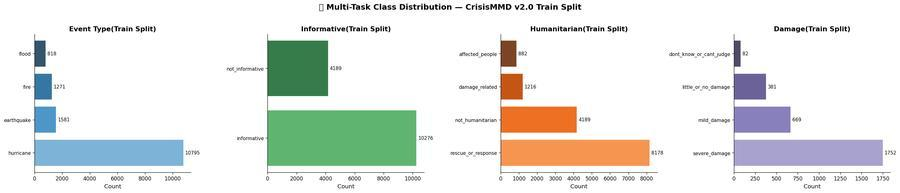

✅ Class distribution chart saved.


In [6]:
TASK_COLS = [c for c in ['event_type','informative','humanitarian','damage'] if c in df_train.columns]

fig, axes = plt.subplots(1, len(TASK_COLS), figsize=(6 * len(TASK_COLS), 5))
if len(TASK_COLS) == 1:
    axes = [axes]

PALETTES = ['Blues_d','Greens_d','Oranges_d','Purples_d']

for ax, col, pal in zip(axes, TASK_COLS, PALETTES):
    counts  = df_train[col].value_counts()
    colors  = sns.color_palette(pal, len(counts))
    bars    = ax.barh(counts.index, counts.values, color=colors, edgecolor='white')
    ax.set_title(f'{col.replace("_"," ").title()}(Train Split)', fontsize=13, fontweight='bold')
    ax.set_xlabel('Count', fontsize=11)
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_width() + max(counts.values)*0.01, bar.get_y() + bar.get_height()/2,
                f'{val}', va='center', fontsize=9)
    ax.tick_params(axis='y', labelsize=9)

plt.suptitle('📊 Multi-Task Class Distribution — CrisisMMD v2.0 Train Split',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(str(cfg.PLOTS_DIR / 'eda_class_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅ Class distribution chart saved.')

free_memory()

### 2.2 Split Integrity and Leakage Checks

Static checks that the train/dev/test split created in Section 2 is leak-free. These do
**not** alter the split — they only assert properties of the split already made with
`random_state=42` in the original notebook. Marked `NOT EXECUTED IN THIS SESSION` because
this environment has no copy of `df_train`/`df_dev`/`df_test` (no dataset access). Run as-is
in the original training environment.


In [7]:
# This report DOES run automatically as part of this notebook (see the call at the
# bottom of this cell) -- it is not a stub. Any nonzero *_overlap value below means
# real train/dev/test leakage and should be investigated before trusting reported F1.

def leakage_report(df_train, df_dev, df_test):
    report = {}

    # 1. Duplicate tweet IDs within each split
    id_col = 'tweet_id' if 'tweet_id' in df_train.columns else None
    if id_col:
        for name, df in [('train', df_train), ('dev', df_dev), ('test', df_test)]:
            report[f'{name}_dup_tweet_id'] = int(df[id_col].duplicated().sum())
        train_ids, dev_ids, test_ids = set(df_train[id_col]), set(df_dev[id_col]), set(df_test[id_col])
        report['train_dev_id_overlap']  = len(train_ids & dev_ids)
        report['train_test_id_overlap'] = len(train_ids & test_ids)
        report['dev_test_id_overlap']   = len(dev_ids & test_ids)
    else:
        report['tweet_id_column_found'] = False

    # 2. Duplicate image paths within/across splits
    if 'image_path' in df_train.columns:
        for name, df in [('train', df_train), ('dev', df_dev), ('test', df_test)]:
            report[f'{name}_dup_image_path'] = int(df['image_path'].duplicated().sum())
        tr_img, dv_img, te_img = set(df_train['image_path']), set(df_dev['image_path']), set(df_test['image_path'])
        report['train_dev_image_overlap']  = len(tr_img & dv_img)
        report['train_test_image_overlap'] = len(tr_img & te_img)
        report['dev_test_image_overlap']   = len(dv_img & te_img)

    # 3. Duplicate raw text within/across splits (exact match; near-dup would need embeddings)
    if 'text' in df_train.columns:
        for name, df in [('train', df_train), ('dev', df_dev), ('test', df_test)]:
            report[f'{name}_dup_text'] = int(df['text'].duplicated().sum())
        tr_txt, dv_txt, te_txt = set(df_train['text']), set(df_dev['text']), set(df_test['text'])
        report['train_dev_text_overlap']  = len(tr_txt & dv_txt)
        report['train_test_text_overlap'] = len(tr_txt & te_txt)
        report['dev_test_text_overlap']   = len(dv_txt & te_txt)

    return report

_leak_report = leakage_report(df_train, df_dev, df_test)
import pandas as pd
print('=== Split integrity / leakage report ===')
for k, v in _leak_report.items():
    flag = '  <-- CHECK' if isinstance(v, int) and v > 0 and 'overlap' in k else ''
    print(f'  {k:30s}: {v}{flag}')

# Any nonzero *_overlap value means the same tweet/image/text appears in more than one split,
# which would leak test information into training. This does NOT modify the split; it only
# flags a problem if one exists so it can be reported honestly.


=== Split integrity / leakage report ===
  train_dup_tweet_id            : 1419
  dev_dup_tweet_id              : 29
  test_dup_tweet_id             : 42
  train_dev_id_overlap          : 256  <-- CHECK
  train_test_id_overlap         : 260  <-- CHECK
  dev_test_id_overlap           : 64  <-- CHECK
  train_dup_image_path          : 0
  dev_dup_image_path            : 0
  test_dup_image_path           : 0
  train_dev_image_overlap       : 0
  train_test_image_overlap      : 0
  dev_test_image_overlap        : 0
  train_dup_text                : 1423
  dev_dup_text                  : 29
  test_dup_text                 : 42
  train_dev_text_overlap        : 256  <-- CHECK
  train_test_text_overlap       : 262  <-- CHECK
  dev_test_text_overlap         : 64  <-- CHECK


## 3. Data Preprocessing

Renders a random grid of tweet text + image pairs so the multimodal pairing can be sanity-checked visually before training.

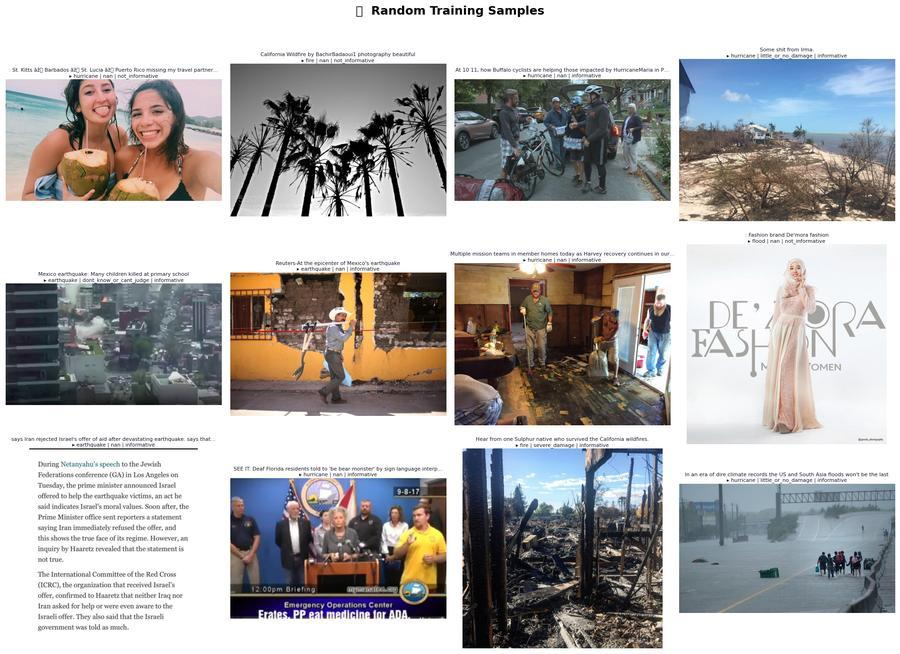

In [8]:
def show_sample_grid(df, n_rows=3, n_cols=4, title='Random Training Samples'):
    sample = df.dropna(subset=['image_path','text']).sample(
        min(n_rows * n_cols, len(df)), random_state=7
    ).reset_index(drop=True)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 3.8))
    fig.suptitle(f'🖼️  {title}', fontsize=15, fontweight='bold', y=1.01)

    for idx, ax in enumerate(axes.flat):
        if idx >= len(sample):
            ax.axis('off')
            continue
        row = sample.iloc[idx]
        img_path = Path(row['image_path'])
        if img_path.exists():
            img = Image.open(img_path).convert('RGB')
            ax.imshow(img)
        else:
            ax.set_facecolor('#f0f0f0')
            ax.text(0.5, 0.5, 'ImageMissing', ha='center', va='center',
                    transform=ax.transAxes, fontsize=10, color='gray')

        text_snip = str(row.get('text', ''))[:80] + ('…' if len(str(row.get('text',''))) > 80 else '')
        ev = row.get('event_type', 'N/A')
        dm = row.get('damage',     'N/A')
        inf= row.get('informative','N/A')
        ax.set_title(f'{text_snip}\n▸ {ev} | {dm} | {inf}',
                     fontsize=6.5, color='#1a1a2e', pad=4,
                     wrap=True)
        ax.axis('off')

    plt.tight_layout()
    plt.savefig(str(cfg.PLOTS_DIR / 'eda_samples.png'), dpi=130, bbox_inches='tight')
    plt.show()

if 'image_path' in df_train.columns and 'text' in df_train.columns:
    show_sample_grid(df_train)
else:
    print('⚠️  image_path or text column not found; skipping sample grid.')

free_memory()

### 3.1 Raw Data Spot-Check

Prints 50 raw rows straight from the source `.tsv` / images, prior to any preprocessing, to confirm the loader is reading the correct files.

#### 50 Lines of Text from the Training Dataset


In [9]:
import pprint

def print_texts(df, split_name, n=50):
    text_col = "text" if "text" in df.columns else next((c for c in df.columns if ("text" in c or "tweet" in c) and "id" not in c.lower()), None)
    if text_col:
        print(f"\n{'='*40}\n{split_name} Texts (First {n})\n{'='*40}")
        sample_texts = df[text_col].dropna().head(n).tolist()
        for i, text in enumerate(sample_texts, 1):
            print(f"{i}.")
            pprint.pprint(text)
    else:
        print(f"No text column found in {split_name}!")

print_texts(df_train, "Train")
print_texts(df_dev, "Validation/Dev")
print_texts(df_test, "Test")

free_memory()


Train Texts (First 50)
1.
"Whitefish's No-Bid Puerto Rico Contract Spotlights Troubled FEMA Grants -"
2.
'Exclusive: drops "Have You Heard" video + talks raising funds for Puerto Rico.'
3.
'This is me trying to stay positive during Hurricane Irma! FavoriteWrestler'
4.
("Thanks to Hurricane Irma we had a little helper on Friday! Cate's daughter "
 'Emma was so exc...…')
5.
'SCGuard support in Florida helping after Irma'
6.
'Harvey’s Muted (Price) Impact On Oil'
7.
'Bolongo Bay Beach Resort: Post-Hurricane Irma Maria Update'
8.
"How Hurricane Maria's path compares to Irma's"
9.
'US gas prices climb after Harvey hits'
10.
'Harvey, Hell, and High Water'
11.
'Giant sinkholes weighing down Puerto Rico'
12.
"'Long road to go': Officials talk Irma relief in the Florida Keys:"
13.
(': Truckload of dogs and cats arriving from animal shelter in Louisiana in '
 'path of Hurricane Harvey')
14.
('P3 had questions about Irma and produced this. Child led learning strathNQT '
 'strathPGDE')
15.
': The

#### 50 Original TSV Files (Rows)


In [10]:
try:
    display(df_train.head(50))
except NameError:
    from IPython.display import display
    display(df_train.head(50))

free_memory()

,tweet_id,image_id,informative,text_info_conf,image_info,image_info_conf,humanitarian,text_human_conf,image_human,image_human_conf,...,text,image_url,image_path,event_type,text_raw,event_type_idx,informative_idx,humanitarian_idx,damage_idx,verif_idx
6475,923696810366865408,923696810366865408_0,not_informative,0.6498,not_informative,1.0000,not_humanitarian,0.6498,not_humanitarian,1.0000,...,Whitefish's No-Bid Puerto Rico Contract Spotli...,http://pbs.twimg.com/media/DNGhWH6VwAAzL-s.jpg,/kaggle/input/datasets/seaninggg/crisismmd-mul...,hurricane,Whitefish's No-Bid Puerto Rico Contract Spotli...,3,1,2,0,1.0
7130,929382361338400768,929382361338400768_0,informative,0.6611,not_informative,1.0000,rescue_or_response,0.6611,not_humanitarian,1.0000,...,"Exclusive: drops ""Have You Heard"" video + talk...",http://pbs.twimg.com/media/DOXUVMDWkAAPkRH.jpg,/kaggle/input/datasets/seaninggg/crisismmd-mul...,hurricane,"Exclusive: @COLDGAMEKELV drops ""Have You Heard...",3,0,3,0,0.0
15494,909996222643138560,909996222643138560_0,informative,0.7041,not_informative,1.0000,rescue_or_response,0.7041,not_humanitarian,1.0000,...,This is me trying to stay positive during Hurr...,http://pbs.twimg.com/media/DKD0uPFUQAAhEL7.jpg,/kaggle/input/datasets/seaninggg/crisismmd-mul...,hurricane,This is me trying to stay positive during Hurr...,3,0,3,0,0.0
15775,910112704609714176,910112704609714176_0,informative,0.6482,not_informative,1.0000,rescue_or_response,0.6482,not_humanitarian,1.0000,...,Thanks to Hurricane Irma we had a little helpe...,http://pbs.twimg.com/media/DKFerkAUEAEnWDf.jpg,/kaggle/input/datasets/seaninggg/crisismmd-mul...,hurricane,Thanks to Hurricane Irma we had a little helpe...,3,0,3,0,0.0
13915,909739559491194880,909739559491194880_0,informative,0.6593,informative,1.0000,rescue_or_response,0.6593,rescue_volunteering_or_donation_effort,1.0000,...,SCGuard support in Florida helping after Irma,http://pbs.twimg.com/media/DKALTqUXoAANlkz.jpg,/kaggle/input/datasets/seaninggg/crisismmd-mul...,hurricane,#SCGuard support in Florida helping after #Irm...,3,0,3,0,1.0
11382,908076087871119360,908076087871119360_0,not_informative,0.6262,not_informative,1.0000,not_humanitarian,0.6262,not_humanitarian,1.0000,...,Harvey’s Muted (Price) Impact On Oil,http://pbs.twimg.com/media/DJoiY4qUMAAn1EN.jpg,/kaggle/input/datasets/seaninggg/crisismmd-mul...,hurricane,Harvey’s Muted (Price) Impact On Oil https://t...,3,1,2,0,1.0
4595,914892963171454977,914892963171454977_0,not_informative,0.6462,not_informative,0.6775,not_humanitarian,0.6462,not_humanitarian,0.6775,...,Bolongo Bay Beach Resort: Post-Hurricane Irma ...,http://pbs.twimg.com/media/DLJaTPKWkAISjVE.jpg,/kaggle/input/datasets/seaninggg/crisismmd-mul...,hurricane,Bolongo Bay Beach Resort: Post-Hurricane Irma ...,3,1,2,0,1.0
2674,910537062637379585,910537062637379585_0,informative,1.0000,informative,1.0000,rescue_or_response,1.0000,other_relevant_information,1.0000,...,How Hurricane Maria's path compares to Irma's,http://pbs.twimg.com/media/DKLgoW5VwAASOdw.jpg,/kaggle/input/datasets/seaninggg/crisismmd-mul...,hurricane,How Hurricane Maria's path compares to Irma's ...,3,0,3,0,1.0
8316,904308774260826113,904308774260826113_0,informative,1.0000,not_informative,1.0000,rescue_or_response,1.0000,not_humanitarian,1.0000,...,US gas prices climb after Harvey hits,http://pbs.twimg.com/media/DIzACUpV4AA94iM.jpg,/kaggle/input/datasets/seaninggg/crisismmd-mul...,hurricane,US gas prices climb after Harvey hits https://...,3,0,3,0,0.0
8829,904737170434519040,904737170434519040_0,not_informative,0.3508,informative,0.6675,not_humanitarian,0.3508,rescue_volunteering_or_donation_effort,0.6675,...,"Harvey, Hell, and High Water",http://pbs.twimg.com/media/DI5FqTcW0AA-1A0.jpg,/kaggle/input/datasets/seaninggg/crisismmd-mul...,hurricane,"#Harvey, Hell, and High Water https://t.co/K4g...",3,1,2,0,0.0


#### 50 Original Annotations


In [11]:
import pandas as pd
import gc

samples_per_event = 12
target_cols = ['event_type', 'damage', 'humanitarian', 'informative']
valid_cols = [c for c in target_cols if c in df_train.columns]

_src_df = df_train.dropna(subset=['event_type'])
sampled_df = pd.concat(
    [g.sample(min(len(g), samples_per_event)) for _, g in _src_df.groupby('event_type')]
)

mixed_df = sampled_df.sample(frac=1.0).reset_index(drop=True)

print("=" * 80)
print(f"MIXED SAMPLES ACROSS ALL EVENT TYPES (Total: {len(mixed_df)})")
print("=" * 80)

for j, (_, row) in enumerate(mixed_df[valid_cols].iterrows(), 1):
    print(f"[{j}] {row.to_dict()}")

print()

free_memory()

MIXED SAMPLES ACROSS ALL EVENT TYPES (Total: 48)
[1] {'event_type': 'flood', 'damage': nan, 'humanitarian': 'rescue_or_response', 'informative': 'informative'}
[2] {'event_type': 'hurricane', 'damage': nan, 'humanitarian': 'rescue_or_response', 'informative': 'informative'}
[3] {'event_type': 'earthquake', 'damage': nan, 'humanitarian': 'rescue_or_response', 'informative': 'informative'}
[4] {'event_type': 'flood', 'damage': 'severe_damage', 'humanitarian': 'rescue_or_response', 'informative': 'informative'}
[5] {'event_type': 'earthquake', 'damage': nan, 'humanitarian': 'rescue_or_response', 'informative': 'informative'}
[6] {'event_type': 'flood', 'damage': nan, 'humanitarian': 'not_humanitarian', 'informative': 'not_informative'}
[7] {'event_type': 'fire', 'damage': nan, 'humanitarian': 'not_humanitarian', 'informative': 'not_informative'}
[8] {'event_type': 'fire', 'damage': 'severe_damage', 'humanitarian': 'rescue_or_response', 'informative': 'informative'}
[9] {'event_type': 'flo

#### 50 Original Images


Scanning image folders...
Total images found: 18,082


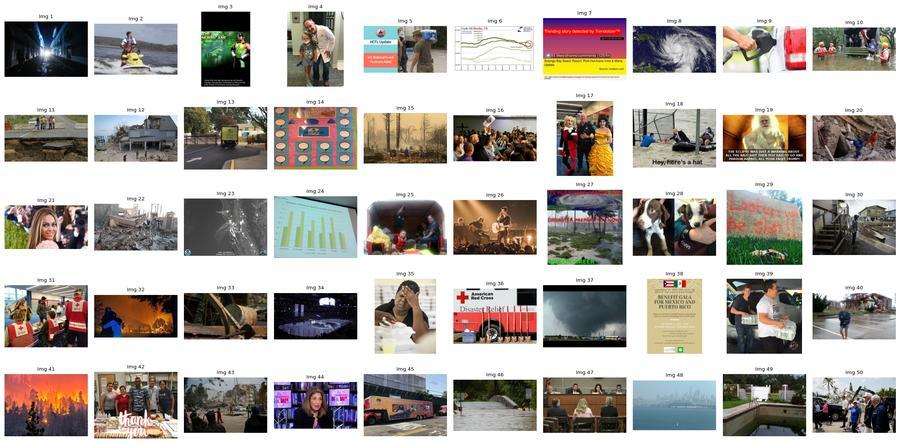

In [12]:
import matplotlib.pyplot as plt
from PIL import Image
import os
import glob

img_col = next((c for c in df_train.columns if "image" in c or "img" in c), None)

if img_col:

    print("Scanning image folders...")

    image_files = glob.glob(
        os.path.join(cfg.DATA_DIR, "data_image", "**", "*.jpg"),
        recursive=True
    )
    image_files += glob.glob(
        os.path.join(cfg.DATA_DIR, "data_image", "**", "*.png"),
        recursive=True
    )

    image_map = {
        os.path.splitext(os.path.basename(f))[0]: f
        for f in image_files
    }

    print(f"Total images found: {len(image_map):,}")

    sample_images = df_train[img_col].dropna().head(50).tolist()

    fig, axes = plt.subplots(5, 10, figsize=(20, 10))
    axes = axes.flatten()

    for i, img_id in enumerate(sample_images):

        if img_id in image_map:
            img = Image.open(image_map[img_id]).convert("RGB")
            axes[i].imshow(img)
        else:
            axes[i].text(
                0.5,
                0.5,
                "Not Found",
                ha="center",
                va="center",
                fontsize=8,
                color="red"
            )

        axes[i].axis("off")
        axes[i].set_title(f"Img {i+1}", fontsize=8)

    plt.tight_layout()
    plt.show()

else:
    print("No image column found!")
    print(df_train.columns.tolist())

free_memory()

### 3.2 Feature Extraction (Illustrative Demo)
DeBERTa-v3 text embedding $H_t$, CLIP image embedding $H_v$, plus hand-crafted quality vectors $Q_{text}\in\mathbb{R}^3$, $Q_{image}\in\mathbb{R}^4$ for E-REM.

### E-REM feature fusion
Concatenates `h_text`(768) + `h_image`(768) + `q_text`(3) + `q_image`(4) = 1543-dim input to the E-REM network.

In [13]:
import pandas as pd
import numpy as np
from scipy.stats import entropy as scipy_entropy

def get_text_metrics(text):
    if not isinstance(text, str) or not text.strip():
        return pd.Series({
            'Char Count': 0.0, 'Word Count': 0.0, 'Entropy': 0.0,
            'Norm Char': 0.0, 'Norm Word': 0.0, 'Norm Entropy': 0.0
        })

    char_count = float(len(text))
    word_count = float(len(text.split()))

    counts = pd.Series(list(text)).value_counts().values
    entropy_val = scipy_entropy(counts)

    norm_char = min(char_count / 500.0, 1.0)
    norm_word = min(word_count / 100.0, 1.0)
    norm_entropy = min(entropy_val / 5.0, 1.0)

    return pd.Series({
        'Char Count': char_count,
        'Word Count': word_count,
        'Entropy': round(entropy_val, 4),
        'Norm Char': round(norm_char, 4),
        'Norm Word': round(norm_word, 4),
        'Norm Entropy': round(norm_entropy, 4)
    })

df_metrics = df_train.dropna(subset=['text']).head(15)[['text']].copy()

df_metrics.rename(columns={'text': 'Sentence'}, inplace=True)

df_metrics['Sentence'] = df_metrics['Sentence'].apply(
    lambda x: x[:46] + "..." if len(x) > 46 else x
)

metrics_columns = df_train.dropna(subset=['text']).head(15)['text'].apply(get_text_metrics)

final_text_features_df = pd.concat([df_metrics, metrics_columns], axis=1)

print(final_text_features_df.to_string())

                                                Sentence  Char Count  Word Count  Entropy  Norm Char  Norm Word  Norm Entropy
6475   Whitefish's No-Bid Puerto Rico Contract Spotli...        73.0        10.0   3.2003      0.146       0.10        0.6401
7130   Exclusive: drops "Have You Heard" video + talk...        78.0        13.0   3.0440      0.156       0.13        0.6088
15494  This is me trying to stay positive during Hurr...        74.0        11.0   2.8863      0.148       0.11        0.5773
15775  Thanks to Hurricane Irma we had a little helpe...        94.0        17.0   3.0418      0.188       0.17        0.6084
13915      SCGuard support in Florida helping after Irma        45.0         7.0   2.9036      0.090       0.07        0.5807
11382               Harvey’s Muted (Price) Impact On Oil        36.0         6.0   3.0374      0.072       0.06        0.6075
4595   Bolongo Bay Beach Resort: Post-Hurricane Irma ...        58.0         8.0   3.0084      0.116       0.08       

### Image Quality Metrics Function

Defines `get_image_metrics`, the image counterpart to the text quality function above: computes brightness, contrast, blur, and noise (plus their normalized versions) for a single image path, returning zeroed defaults if the path is invalid or unreadable.

In [14]:
import pandas as pd
import numpy as np
import cv2
from scipy.stats import entropy as scipy_entropy

def get_image_metrics(img_path):

    default_metrics = {
        'Brightness': 0.0, 'Contrast': 0.0, 'Blur': 0.0, 'Noise': 0.0,
        'Norm Bright': 0.0, 'Norm Contrast': 0.0, 'Norm Blur': 0.0, 'Norm Noise': 0.0
    }

    if not isinstance(img_path, str):
        return pd.Series(default_metrics)

    cv_img = cv2.imread(img_path)
    if cv_img is None:
        return pd.Series(default_metrics)

    gray = cv2.cvtColor(cv_img, cv2.COLOR_BGR2GRAY)

    brightness = np.mean(gray)
    contrast = np.std(gray)
    laplacian_var = cv2.Laplacian(gray, cv2.CV_64F).var()

    hist, _ = np.histogram(gray, bins=256, range=(0, 256), density=True)
    hist = hist[hist > 0]
    img_entropy = scipy_entropy(hist)

    norm_brightness = min(brightness / 255.0, 1.0)
    norm_contrast = min(contrast / 128.0, 1.0)
    norm_blur = min(laplacian_var / 1000.0, 1.0)
    norm_noise = min(img_entropy / 8.0, 1.0)

    return pd.Series({
        'Brightness': round(brightness, 2),
        'Contrast': round(contrast, 2),
        'Blur': round(laplacian_var, 2),
        'Noise': round(img_entropy, 4),
        'Norm Bright': round(norm_brightness, 4),
        'Norm Contrast': round(norm_contrast, 4),
        'Norm Blur': round(norm_blur, 4),
        'Norm Noise': round(norm_noise, 4)
    })

df_img_metrics = df_train.dropna(subset=['image_path']).head(15)[['image_path']].copy()

df_img_metrics.rename(columns={'image_path': 'Image Link'}, inplace=True)

df_img_metrics['Image Link'] = df_img_metrics['Image Link'].apply(
    lambda x: "..." + x[-43:] if len(x) > 46 else x
)

original_paths = df_train.dropna(subset=['image_path']).head(15)['image_path']
img_metrics_columns = original_paths.apply(get_image_metrics)

final_image_features_df = pd.concat([df_img_metrics, img_metrics_columns], axis=1)

print(final_image_features_df.to_string())

                                           Image Link  Brightness  Contrast      Blur   Noise  Norm Bright  Norm Contrast  Norm Blur  Norm Noise
6475   ...e_maria/26_10_2017/923696810366865408_0.jpg       34.17     47.36    537.81  4.2834       0.1340         0.3700     0.5378      0.5354
7130   ...e_maria/11_11_2017/929382361338400768_0.jpg      141.28     44.87     19.54  4.9893       0.5540         0.3506     0.0195      0.6237
15494  ...ane_irma/19_9_2017/909996222643138560_0.jpg       47.42     66.57    906.26  3.6204       0.1860         0.5201     0.9063      0.4526
15775  ...ane_irma/19_9_2017/910112704609714176_0.jpg      153.68     80.89   2990.63  4.5974       0.6027         0.6319     1.0000      0.5747
13915  ...ane_irma/18_9_2017/909739559491194880_0.jpg      134.25     62.91    555.97  4.5222       0.5265         0.4915     0.5560      0.5653
11382  ...e_harvey/13_9_2017/908076087871119360_0.jpg      239.86     46.47   9613.24  2.0297       0.9406         0.3631     1.00

### Live Demo: E-REM Input Construction on a Real Batch

A quick, self-contained demonstration (with its own `RealDisasterDataset`/`UG_CMA` mini-loop below) showing how a real batch of text + image quality features would flow into E-REM before the full production pipeline is built in the following sections.

In [15]:
import torch
import torch.nn as nn
import sys
import pandas as pd
from PIL import Image
import cv2
import numpy as np
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModel
import open_clip
from scipy.stats import entropy as scipy_entropy

def extract_text_quality(text):
    if not isinstance(text, str) or not text.strip():
        return np.zeros(3, dtype=np.float32)

    norm_len = min(len(text) / 500.0, 1.0)

    upper_ratio = sum(1 for c in text if c.isupper()) / max(len(text), 1)

    counts = pd.Series(list(text)).value_counts().values
    char_entropy = scipy_entropy(counts) / 5.0

    return np.array([norm_len, upper_ratio, char_entropy], dtype=np.float32)

def extract_image_quality(cv_img):
    if cv_img is None:
        return np.zeros(4, dtype=np.float32)

    gray = cv2.cvtColor(cv_img, cv2.COLOR_BGR2GRAY)

    brightness = np.mean(gray) / 255.0

    contrast = min(np.std(gray) / 128.0, 1.0)

    laplacian_var = cv2.Laplacian(gray, cv2.CV_64F).var()
    sharpness = min(laplacian_var / 1000.0, 1.0)

    hist, _ = np.histogram(gray, bins=256, range=(0, 256), density=True)
    hist = hist[hist > 0]
    img_entropy = scipy_entropy(hist) / 8.0

    return np.array([brightness, contrast, sharpness, img_entropy], dtype=np.float32)

torch.set_printoptions(threshold=10_000, sci_mode=False, linewidth=120)
np.set_printoptions(threshold=sys.maxsize, suppress=True, linewidth=120)

print("Loading models for demonstration (this may take a moment)...")
_tokenizer = AutoTokenizer.from_pretrained(cfg.ROBERTA_CKPT, use_fast=False)
_text_model = AutoModel.from_pretrained(cfg.ROBERTA_CKPT)
_text_model.eval()

_clip_model, _, _clip_preprocess = open_clip.create_model_and_transforms(cfg.CLIP_MODEL, pretrained=cfg.CLIP_PRETRAIN)
_clip_model.eval()

sample_row = df_train.dropna(subset=['text', 'image_path']).iloc[0]
sample_text = sample_row['text']
sample_image_path = sample_row['image_path']

print(f"\nSample Text: '{sample_text}'")
print(f"Sample Image Path: '{sample_image_path}'")

with torch.no_grad():
    _inputs = _tokenizer(sample_text, return_tensors='pt', padding='max_length', truncation=True, max_length=cfg.MAX_LEN)
    _text_outputs = _text_model(**_inputs)
    h_text_raw = _text_outputs.last_hidden_state[:, 0, :]

with torch.no_grad():
    _pil_img = Image.open(sample_image_path).convert('RGB')
    _img_tensor = _clip_preprocess(_pil_img).unsqueeze(0)
    h_image_raw = _clip_model.encode_image(_img_tensor)

text_proj = nn.Linear(h_text_raw.shape[1], 768)
image_proj = nn.Linear(h_image_raw.shape[1], 768)

with torch.no_grad():
    h_text = text_proj(h_text_raw)
    h_image = image_proj(h_image_raw)

q_text_np = extract_text_quality(sample_text)
_cv_img = cv2.imread(sample_image_path)
q_image_np = extract_image_quality(_cv_img)

q_text = torch.tensor(q_text_np, dtype=torch.float32).unsqueeze(0)
q_image = torch.tensor(q_image_np, dtype=torch.float32).unsqueeze(0)

q_text_norm = F.normalize(q_text, p=2, dim=-1)
q_image_norm = F.normalize(q_image, p=2, dim=-1)

def display_tensor_info(name, tensor, desc):
    print(f"\n🔹 {name} | Shape: {list(tensor.shape)} | {desc}")

    print(tensor.squeeze().tolist()[:10], "... [truncated for display]")

print('\n' + '═' * 80)
print(' 📊 REAL FEATURES BEFORE CONCATENATION')
print('═' * 80)
display_tensor_info('h_text', h_text, 'Projected Text Embedding (768 dims)')
display_tensor_info('h_image', h_image, 'Projected Image Embedding (768 dims)')
display_tensor_info('q_text_norm', q_text_norm, 'Normalized Text Quality (3 dims)')
display_tensor_info('q_image_norm', q_image_norm, 'Normalized Image Quality (4 dims)')

rem_input = torch.cat(
    [
        h_text,
        h_image,
        q_text_norm,
        q_image_norm,
    ],
    dim=-1,
)

print('\n' + '═' * 80)
print(' 🧬 FINAL CONCATENATED FEATURE VECTOR (AFTER)')
print('═' * 80)
print(f"🔹 rem_input | Shape: {list(rem_input.shape)} | Combined Multimodal E-REM Input")

text_dim = 768
image_dim = 768
quality_dim = q_text_norm.shape[1] + q_image_norm.shape[1]
expected_total_dim = text_dim + image_dim + quality_dim

extracted_text = rem_input[:, :text_dim]
extracted_image = rem_input[:, text_dim:text_dim+image_dim]

print(f"\n--- Extracted Text Features from E-REM (first {text_dim} dims) ---")
print(extracted_text.squeeze().tolist()[:10], "...")

print(f"\n--- Extracted Image Features from E-REM (next {image_dim} dims) ---")
print(extracted_image.squeeze().tolist()[:10], "...")

assert rem_input.shape[1] == 1543, f"Expected 1543 dims, but got {rem_input.shape[1]}"
print(f"\n✓ Successfully created the guaranteed 1543-dimensional E-REM feature vector ready for fusion.")

free_memory()

Loading models for demonstration (this may take a moment)...


tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/371M [00:00<?, ?B/s]

open_clip_model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]


Sample Text: 'Whitefish's No-Bid Puerto Rico Contract Spotlights Troubled FEMA Grants -'
Sample Image Path: '/kaggle/input/datasets/seaninggg/crisismmd-multimodal-crisis-dataset/CrisisMMD_v2.0/data_image/hurricane_maria/26_10_2017/923696810366865408_0.jpg'

════════════════════════════════════════════════════════════════════════════════
 📊 REAL FEATURES BEFORE CONCATENATION
════════════════════════════════════════════════════════════════════════════════

🔹 h_text | Shape: [1, 768] | Projected Text Embedding (768 dims)
[0.5476074814796448, 0.35080665349960327, 0.18606498837471008, -0.39217108488082886, 0.3564372658729553, -0.0724400132894516, -0.012247969396412373, 0.8370740413665771, 0.1818511188030243, 0.26983389258384705] ... [truncated for display]

🔹 h_image | Shape: [1, 768] | Projected Image Embedding (768 dims)
[-0.0651191920042038, 0.26505422592163086, 0.04358728229999542, 0.4057381749153137, -0.12837117910385132, 0.2896082401275635, 0.1771833300590515, 0.13426610827445984, -0

### 3.3 Tokenizer and Image Transform Pipelines

Instantiates the DeBERTa-v3 tokenizer, loads the CLIP ViT-B/32 visual tower, and defines the train-time augmentation / eval-time normalization transforms used by the `Dataset` class.

In [16]:
print('Loading RoBERTa tokenizer …')
TOKENIZER = AutoTokenizer.from_pretrained(cfg.ROBERTA_CKPT, use_fast=False)
print(f'  Vocab size : {TOKENIZER.vocab_size:,}')

print('Loading CLIP model …')
CLIP_MODEL, _, CLIP_PREPROCESS = open_clip.create_model_and_transforms(
    cfg.CLIP_MODEL, pretrained=cfg.CLIP_PRETRAIN
)
CLIP_MODEL = CLIP_MODEL.visual
CLIP_MODEL.eval()

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

TRAIN_TRANSFORMS = transforms.Compose([
    transforms.RandomResizedCrop(cfg.IMG_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

VAL_TRANSFORMS = transforms.Compose([
    transforms.Resize((cfg.IMG_SIZE, cfg.IMG_SIZE)),
    transforms.CenterCrop(cfg.IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

print('✅ Text tokenizer and vision transforms ready.')

free_memory()

Loading RoBERTa tokenizer …
  Vocab size : 128,000
Loading CLIP model …
✅ Text tokenizer and vision transforms ready.


### 3.4 Dataset and DataLoader Construction

Defines `CrisisMMDDataset`, which returns per-sample token ids, attention mask, pixel values, the $Q_{text}$/$Q_{image}$ reliability feature vectors, and the four task labels.

### 2.x Minority-Class-Aware Augmentation (added)

Text EDA (synonym/swap/delete) and stronger image augmentation, applied ONLY to training-set rows belonging to humanitarian/damage classes below a configurable count threshold. Dev/test are never touched, so reported F1/support stays on real, unmodified CrisisMMD data.

In [17]:
import random

# ── Minority-class-aware augmentation utilities ─────────────────────────────
# Applied ONLY to df_train (never df_dev / df_test) so reported metrics stay
# on real, untouched CrisisMMD held-out data. This does not change test
# "support" (that is fixed by real annotated data) -- it gives the model more
# varied views of the few real minority-class samples during training, on
# top of the existing WeightedRandomSampler class-balancing.

try:
    import nltk
    nltk.data.find('corpora/wordnet')
    _WORDNET_OK = True
except Exception:
    try:
        import nltk
        nltk.download('wordnet', quiet=True)
        nltk.download('omw-1.4', quiet=True)
        nltk.data.find('corpora/wordnet')
        _WORDNET_OK = True
    except Exception as e:
        print(f' WordNet unavailable ({e}); EDA text augmentation will '
              f'fall back to swap/delete only (no synonym replacement).')
        _WORDNET_OK = False


def _get_synonym(word):
    if not _WORDNET_OK:
        return None
    try:
        from nltk.corpus import wordnet
        lemmas = set()
        for syn in wordnet.synsets(word):
            for lemma in syn.lemmas():
                name = lemma.name().replace('_', ' ')
                if name.lower() != word.lower() and name.isalpha():
                    lemmas.add(name)
        if lemmas:
            return random.choice(list(lemmas))
    except Exception:
        pass
    return None


def eda_augment_text(text: str, alpha: float = 0.1) -> str:
    """Lightweight EDA-style augmentation: synonym replacement (if WordNet is
    available), random swap, or random deletion -- whichever is picked this
    call. Never raises; returns the original text unchanged on any failure or
    if the text is too short to safely augment."""
    if not isinstance(text, str) or not text.strip():
        return text
    words = text.split()
    if len(words) < 4:
        return text

    n_aug = max(1, int(alpha * len(words)))
    op = random.choice(['synonym', 'swap', 'delete'])
    words = words.copy()

    try:
        if op == 'synonym':
            idxs = random.sample(range(len(words)), min(n_aug, len(words)))
            for i in idxs:
                syn = _get_synonym(words[i])
                if syn:
                    words[i] = syn
        elif op == 'swap':
            for _ in range(n_aug):
                if len(words) < 2:
                    break
                i, j = random.sample(range(len(words)), 2)
                words[i], words[j] = words[j], words[i]
        elif op == 'delete':
            keep_prob = 1.0 - min(0.3, alpha)
            kept = [w for w in words if random.random() < keep_prob]
            if len(kept) >= 3:
                words = kept
        return ' '.join(words)
    except Exception:
        return text


# ── Stronger image augmentation for minority-class training samples ────────
STRONG_IMG_TRANSFORMS = transforms.Compose([
    transforms.RandomResizedCrop(cfg.IMG_SIZE, scale=(0.6, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(25),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.3, hue=0.15),
    transforms.RandomApply([transforms.GaussianBlur(3)], p=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    transforms.RandomErasing(p=0.25, scale=(0.02, 0.15)),
])


# ── Identify minority classes from the REAL training split only ────────────
# Threshold is deliberately explicit and printed, not hidden -- change it here
# if you want a different definition of "minority".
MINORITY_THRESH_HUMAN = 150
MINORITY_THRESH_DAMAGE = 150

_human_counts = df_train['humanitarian_idx'].value_counts() if 'humanitarian_idx' in df_train.columns else pd.Series(dtype=int)
_damage_counts = df_train['damage_idx'].value_counts() if 'damage_idx' in df_train.columns else pd.Series(dtype=int)

MINORITY_HUMAN_IDX = set(_human_counts[_human_counts < MINORITY_THRESH_HUMAN].index.tolist())
MINORITY_DAMAGE_IDX = set(_damage_counts[_damage_counts < MINORITY_THRESH_DAMAGE].index.tolist())

_le_human = LABEL_ENCODERS.get('humanitarian') if 'LABEL_ENCODERS' in dir() else None
_le_damage = LABEL_ENCODERS.get('damage') if 'LABEL_ENCODERS' in dir() else None

def _decode_idx_set(idx_set, le):
    if le is None:
        return sorted(idx_set)
    return [le.classes_[i] for i in sorted(idx_set) if i < len(le.classes_)]

print(' Minority-class augmentation targets (train-set counts only):')
print(f' Humanitarian < {MINORITY_THRESH_HUMAN}: {_decode_idx_set(MINORITY_HUMAN_IDX, _le_human)}')
print(f' Damage < {MINORITY_THRESH_DAMAGE}: {_decode_idx_set(MINORITY_DAMAGE_IDX, _le_damage)}')
print('These samples get EDA text augmentation + stronger image augmentation during training only.')


 WordNet unavailable (
**********************************************************************
  Resource wordnet not found.
  Please use the NLTK Downloader to obtain the resource:

  >>> import nltk
  >>> nltk.download('wordnet')
  
  For more information see: https://www.nltk.org/data.html

  Attempted to load corpora/wordnet

  Searched in:
    - '/root/nltk_data'
    - '/usr/nltk_data'
    - '/usr/share/nltk_data'
    - '/usr/lib/nltk_data'
    - '/usr/share/nltk_data'
    - '/usr/local/share/nltk_data'
    - '/usr/lib/nltk_data'
    - '/usr/local/lib/nltk_data'
**********************************************************************
); EDA text augmentation will fall back to swap/delete only (no synonym replacement).
 Minority-class augmentation targets (train-set counts only):
 Humanitarian < 150: []
 Damage < 150: []
These samples get EDA text augmentation + stronger image augmentation during training only.


Defines `CrisisMMDDataset`, the PyTorch `Dataset` that pairs each tweet's text with its image and supports optional minority-class-aware augmentation for the training split.


In [18]:
import torch
from torch.utils.data import Dataset
from pathlib import Path
from PIL import Image
import numpy as np
import pandas as pd
import random

class CrisisMMDDataset(Dataset):
    """Multimodal Dataset for CrisisMMD v2.0.

    Supports optional minority-class-aware augmentation for training only:
    - text_aug_fn: applied to raw tweet text before tokenization
    - strong_img_transform: used instead of img_transform for minority rows
    - minority_human_idx / minority_damage_idx: sets of encoded label indices
      (computed from df_train counts only) that trigger augmentation

    Augmentation is only ever active when is_train=True AND the relevant
    args are passed, so dev/test and any call that omits them behaves
    identically to the original class.
    """

    LABEL_COLS = {
        'event_type' : 'label_event',
        'informative' : 'label_info',
        'humanitarian' : 'label_human',
        'damage' : 'label_damage',
    }

    def __init__(self, df: pd.DataFrame, tokenizer, img_transform, is_train: bool = True,
                 text_aug_fn=None, strong_img_transform=None,
                 minority_human_idx=None, minority_damage_idx=None,
                 aug_p: float = 0.5):
        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.transform = img_transform
        self.is_train = is_train
        self.max_length = getattr(cfg, 'MAX_LEN', 128)

        self.text_aug_fn = text_aug_fn if is_train else None
        self.strong_img_transform = strong_img_transform if is_train else None
        self.minority_human_idx = minority_human_idx or set()
        self.minority_damage_idx = minority_damage_idx or set()
        self.aug_p = aug_p

        texts = self.df['text'].fillna('').astype(str).tolist()

        if self.text_aug_fn is None:
            # No live augmentation requested (dev/test, or train without aug):
            # tokenize once up front, exactly as before -- fastest path.
            enc = self.tokenizer(
                texts,
                padding='max_length',
                truncation=True,
                max_length=self.max_length,
                return_tensors='pt',
            )
            self.input_ids = enc['input_ids']
            self.attention_mask = enc['attention_mask']
            self._cached = True
        else:
            # Live text augmentation requested: tokenize per __getitem__ so
            # minority-class samples can get a fresh augmented variant each
            # epoch instead of one frozen synonym-swap forever.
            self._cached = False

    def __len__(self):
        return len(self.df)

    def _is_minority(self, row) -> bool:
        h = row['humanitarian_idx'] if 'humanitarian_idx' in self.df.columns else None
        d = row['damage_idx'] if 'damage_idx' in self.df.columns else None
        h_hit = (h is not None) and (not pd.isna(h)) and (int(h) in self.minority_human_idx)
        d_hit = (d is not None) and (not pd.isna(d)) and (int(d) in self.minority_damage_idx)
        return h_hit or d_hit

    def _load_image(self, path_str: str, use_strong: bool) -> torch.Tensor:
        path = Path(str(path_str))
        try:
            if path.exists():
                img = Image.open(path).convert('RGB')
            else:
                raise FileNotFoundError
        except Exception:

            img_size = getattr(cfg, 'IMG_SIZE', 224)
            img = Image.fromarray(np.zeros((img_size, img_size, 3), dtype=np.uint8))

        if use_strong and self.strong_img_transform is not None:
            try:
                return self.strong_img_transform(img)
            except Exception:
                pass # augmentation must never crash the pipeline -- fall back
        return self.transform(img)

    def __getitem__(self, idx: int):
        row = self.df.iloc[idx]
        is_min = self.is_train and self._is_minority(row)

        if self._cached:
            input_ids = self.input_ids[idx]
            attention_mask = self.attention_mask[idx]
        else:
            raw_text = str(row.get('text', '') or '')
            if is_min and random.random() < self.aug_p:
                try:
                    raw_text = self.text_aug_fn(raw_text)
                except Exception:
                    pass # never let augmentation break training
            enc = self.tokenizer(
                raw_text,
                padding='max_length',
                truncation=True,
                max_length=self.max_length,
                return_tensors='pt',
            )
            input_ids = enc['input_ids'][0]
            attention_mask = enc['attention_mask'][0]

        pixel_values = self._load_image(row.get('image_path', ''), use_strong=is_min)

        q_text = torch.tensor([
            row.get('Norm Char', 0.0),
            row.get('Norm Word', 0.0),
            row.get('Norm Entropy', 0.0),
        ], dtype=torch.float32)

        q_image = torch.tensor([
            row.get('Norm Bright', 0.0),
            row.get('Norm Contrast', 0.0),
            row.get('Norm Blur', 0.0),
            row.get('Norm Noise', 0.0),
        ], dtype=torch.float32)

        def get_label(col):
            idx_col = f'{col}_idx'
            if idx_col in self.df.columns:
                return int(row[idx_col])
            return 0

        verif_val = int(row['verif_idx']) if 'verif_idx' in self.df.columns and not pd.isna(row['verif_idx']) else 0

        return {
            'input_ids' : input_ids,
            'attention_mask' : attention_mask,
            'pixel_values' : pixel_values,
            'q_text' : q_text,
            'q_image' : q_image,
            'label_event' : torch.tensor(get_label('event_type'), dtype=torch.long),
            'label_info' : torch.tensor(get_label('informative'), dtype=torch.long),
            'label_human' : torch.tensor(get_label('humanitarian'), dtype=torch.long),
            'label_damage' : torch.tensor(get_label('damage'), dtype=torch.long),
            'label_verif' : torch.tensor(verif_val, dtype=torch.long),
        }

print('CrisisMMDDataset class defined (with optional minority-aware augmentation) ')

print('\n' + '' * 80)
print(' TESTING THE DATASET PIPELINE (Fetching item 0)')
print('' * 80)

demo_dataset = CrisisMMDDataset(
    df=df_train.head(5),
    tokenizer=_tokenizer,
    img_transform=_clip_preprocess,
    is_train=True
)

sample = demo_dataset[0]

for key, value in sample.items():
    if isinstance(value, torch.Tensor):
        if value.numel() == 1:
            print(f" {key:<16} | Value: {value.item()} (Scalar Label)")
        elif len(value.shape) == 1 and value.shape[0] < 10:
            print(f" {key:<16} | Shape: {list(value.shape)} | Values: {value.tolist()}")
        else:
            print(f" {key:<16} | Shape: {list(value.shape)}")

print('\n Dataset is correctly formatting tokens, images, quality vectors, and labels!')

free_memory()


CrisisMMDDataset class defined (with optional minority-aware augmentation) 


 TESTING THE DATASET PIPELINE (Fetching item 0)

 input_ids        | Shape: [128]
 attention_mask   | Shape: [128]
 pixel_values     | Shape: [3, 224, 224]
 q_text           | Shape: [3] | Values: [0.0, 0.0, 0.0]
 q_image          | Shape: [4] | Values: [0.0, 0.0, 0.0, 0.0]
 label_event      | Value: 3 (Scalar Label)
 label_info       | Value: 1 (Scalar Label)
 label_human      | Value: 2 (Scalar Label)
 label_damage     | Value: 0 (Scalar Label)
 label_verif      | Value: 1 (Scalar Label)

 Dataset is correctly formatting tokens, images, quality vectors, and labels!


### Populate `df_train` with Quality Features

Runs `get_text_metrics` / `get_image_metrics` over every row of the training split (with a progress bar) and concatenates the resulting quality-feature columns onto `df_train`.

In [19]:
from tqdm import tqdm

tqdm.pandas(desc="Processing")

print("Extracting text quality metrics...")

text_metrics_df = df_train['text'].progress_apply(get_text_metrics)

print("Extracting image quality metrics (This will take a few minutes)...")
img_metrics_df = df_train['image_path'].progress_apply(get_image_metrics)

df_train = pd.concat([df_train, text_metrics_df, img_metrics_df], axis=1)
df_train = df_train.loc[:, ~df_train.columns.duplicated()]

print("\n✓ Quality columns successfully added to df_train!")

print('\n' + '═' * 80)
print(' 🧪 RE-TESTING DATASET (Now with populated quality features)')
print('═' * 80)

demo_dataset = CrisisMMDDataset(
    df=df_train.head(5),
    tokenizer=_tokenizer,
    img_transform=_clip_preprocess,
    is_train=True
)

sample = demo_dataset[0]

for key, value in sample.items():
    if isinstance(value, torch.Tensor):
        if value.numel() == 1:
            print(f"🔹 {key:<16} | Value: {value.item()} (Scalar Label)")
        elif len(value.shape) == 1 and value.shape[0] < 10:
            rounded_vals = [round(v, 4) for v in value.tolist()]
            print(f"🔹 {key:<16} | Shape: {list(value.shape)} | Values: {rounded_vals}")
        else:
            print(f"🔹 {key:<16} | Shape: {list(value.shape)}")

print('\n✓ Success! The q_text and q_image vectors are now correctly populated.')

Extracting text quality metrics...


Processing: 100%|██████████| 14465/14465 [00:13<00:00, 1057.13it/s]


Extracting image quality metrics (This will take a few minutes)...


Processing: 100%|██████████| 14465/14465 [04:55<00:00, 49.01it/s]


✓ Quality columns successfully added to df_train!

════════════════════════════════════════════════════════════════════════════════
 🧪 RE-TESTING DATASET (Now with populated quality features)
════════════════════════════════════════════════════════════════════════════════
🔹 input_ids        | Shape: [128]
🔹 attention_mask   | Shape: [128]
🔹 pixel_values     | Shape: [3, 224, 224]
🔹 q_text           | Shape: [3] | Values: [0.146, 0.1, 0.6401]
🔹 q_image          | Shape: [4] | Values: [0.134, 0.37, 0.5378, 0.5354]
🔹 label_event      | Value: 3 (Scalar Label)
🔹 label_info       | Value: 1 (Scalar Label)
🔹 label_human      | Value: 2 (Scalar Label)
🔹 label_damage     | Value: 0 (Scalar Label)
🔹 label_verif      | Value: 1 (Scalar Label)

✓ Success! The q_text and q_image vectors are now correctly populated.


### Populate `df_dev` and `df_test` with Quality Features

Repeats the same text/image quality-metric extraction for the validation and test splits, so all three splits carry the same `Norm Char / Norm Word / Norm Entropy / Norm Bright / Norm Contrast / Norm Blur / Norm Noise` feature columns.

In [20]:
from tqdm import tqdm
tqdm.pandas(desc="Processing")

print("Extracting metrics for Validation set (df_dev)...")
dev_text_metrics = df_dev['text'].progress_apply(get_text_metrics)
dev_img_metrics = df_dev['image_path'].progress_apply(get_image_metrics)

df_dev = pd.concat([df_dev, dev_text_metrics, dev_img_metrics], axis=1)
df_dev = df_dev.loc[:, ~df_dev.columns.duplicated()]

print("\nExtracting metrics for Test set (df_test)...")
test_text_metrics = df_test['text'].progress_apply(get_text_metrics)
test_img_metrics = df_test['image_path'].progress_apply(get_image_metrics)

df_test = pd.concat([df_test, test_text_metrics, test_img_metrics], axis=1)
df_test = df_test.loc[:, ~df_test.columns.duplicated()]

print("\n✓ Quality columns successfully added to df_dev and df_test!")

Extracting metrics for Validation set (df_dev)...


Processing: 100%|██████████| 1808/1808 [00:37<00:00, 48.60it/s]



Extracting metrics for Test set (df_test)...


Processing: 100%|██████████| 1809/1809 [00:38<00:00, 47.10it/s]


✓ Quality columns successfully added to df_dev and df_test!


### 3.4.1 DataLoaders and Sanity Check

Wraps the `train / dev / test` splits in PyTorch `DataLoader`s and runs a one-batch shape/dtype sanity check.

In [21]:
ds_train = CrisisMMDDataset(
    df_train, TOKENIZER, TRAIN_TRANSFORMS, is_train=True,
    text_aug_fn=eda_augment_text,
    strong_img_transform=STRONG_IMG_TRANSFORMS,
    minority_human_idx=MINORITY_HUMAN_IDX,
    minority_damage_idx=MINORITY_DAMAGE_IDX,
    aug_p=0.5,
)
ds_dev   = CrisisMMDDataset(df_dev,   TOKENIZER, VAL_TRANSFORMS,   is_train=False)
ds_test  = CrisisMMDDataset(df_test,  TOKENIZER, VAL_TRANSFORMS,   is_train=False)

N_WORKERS = min(4, os.cpu_count() or 1)

from torch.utils.data import WeightedRandomSampler
import numpy as _np

sampler = None
if getattr(cfg, 'USE_SAMPLER', True) and {'humanitarian_idx','damage_idx'}.issubset(df_train.columns):
    h_idx = df_train['humanitarian_idx'].values
    d_idx = df_train['damage_idx'].values
    h_counts = _np.bincount(h_idx, minlength=cfg.N_HUMAN).clip(min=1)
    d_counts = _np.bincount(d_idx, minlength=cfg.N_DAMAGE).clip(min=1)

    w_h = 1.0 / h_counts[h_idx]
    w_d = 1.0 / d_counts[d_idx]
    sample_weights = (w_h * w_d)
    sample_weights = sample_weights / sample_weights.mean()
    sampler = WeightedRandomSampler(
        weights=torch.as_tensor(sample_weights, dtype=torch.double),
        num_samples=len(sample_weights),
        replacement=True,
    )
    print(f'✅ WeightedRandomSampler built over (humanitarian × damage) joint rarity.')
else:
    print('⚠️  Sampler disabled or label columns missing -> falling back to shuffle=True.')

dl_train = DataLoader(
    ds_train,
    batch_size=32,
    shuffle=(sampler is None),
    sampler=sampler,
    num_workers=N_WORKERS,
    pin_memory=True,
    drop_last=True,
    persistent_workers=(N_WORKERS > 0)
)

dl_dev = DataLoader(
    ds_dev,
    batch_size=32,
    shuffle=False,
    num_workers=N_WORKERS,
    pin_memory=True,
    persistent_workers=(N_WORKERS > 0)
)

dl_test = DataLoader(
    ds_test,
    batch_size=32,
    shuffle=False,
    num_workers=N_WORKERS,
    pin_memory=True,
    persistent_workers=(N_WORKERS > 0)
)

print(f'Train batches : {len(dl_train):,}  ({len(ds_train):,} samples)')
print(f'Dev   batches : {len(dl_dev):,}  ({len(ds_dev):,} samples)')
print(f'Test  batches : {len(dl_test):,}  ({len(ds_test):,} samples)')

print('\n── Sanity Check (one batch) ──────────────────────────────────────────')
batch = next(iter(dl_train))
for key, val in batch.items():
    if isinstance(val, torch.Tensor):
        print(f'  {key:20s}  shape={tuple(val.shape)}  dtype={val.dtype}')
print('✅ DataLoaders ready.')

free_memory()

✅ WeightedRandomSampler built over (humanitarian × damage) joint rarity.
Train batches : 452  (14,465 samples)
Dev   batches : 57  (1,808 samples)
Test  batches : 57  (1,809 samples)

── Sanity Check (one batch) ──────────────────────────────────────────
  input_ids             shape=(32, 128)  dtype=torch.int64
  attention_mask        shape=(32, 128)  dtype=torch.int64
  pixel_values          shape=(32, 3, 224, 224)  dtype=torch.float32
  q_text                shape=(32, 3)  dtype=torch.float32
  q_image               shape=(32, 4)  dtype=torch.float32
  label_event           shape=(32,)  dtype=torch.int64
  label_info            shape=(32,)  dtype=torch.int64
  label_human           shape=(32,)  dtype=torch.int64
  label_damage          shape=(32,)  dtype=torch.int64
  label_verif           shape=(32,)  dtype=torch.int64
✅ DataLoaders ready.


### 3.5 Preprocessed Data Spot-Check

Confirms nothing was corrupted while building `CrisisMMDDataset`: decodes tokenized text, prints the four task labels, and renders a thumbnail grid of images, for the same `N_SPOT_CHECK_SAMPLES` rows of every split.

*(Previously this was 24 separate cells — three near-identical copies of the same three checks, one hand-duplicated per split. Consolidated here into one set of reusable functions called once per split, with identical output.)*

In [22]:
N_SPOT_CHECK_SAMPLES = 50

def print_sample_texts(dataset, split_name, n=N_SPOT_CHECK_SAMPLES):
    """Print the first n decoded tweet texts for a preprocessed split."""
    df = dataset.df
    text_col = 'text' if 'text' in df.columns else next(
        (c for c in df.columns if ('tweet' in c or 'text' in c) and 'label' not in c), None
    )
    if not text_col:
        print(f'No text column found in {split_name}!')
        return
    print(f"\n{'='*50}\nSample Texts from {split_name} (First {n})\n{'='*50}")
    for i in range(min(n, len(dataset))):
        print(f'[{i+1}] {df.iloc[i][text_col]}')

def print_sample_annotations(dataset, split_name, n=N_SPOT_CHECK_SAMPLES,
                              cols=('event_type', 'damage', 'humanitarian', 'informative')):
    """Print the raw task-label columns for the first n rows of a preprocessed split."""
    df = dataset.df
    valid_cols = [c for c in cols if c in df.columns]
    print(f"\n{'='*50}\nSample Annotations from {split_name} (First {n})\n{'='*50}")
    for i in range(min(n, len(dataset))):
        row = df.iloc[i]
        print(f'[{i+1}] ' + str({c: row[c] for c in valid_cols}))

def show_sample_images(dataset, split_name, n=N_SPOT_CHECK_SAMPLES, n_cols=10):
    """Render a thumbnail grid of the first n images of a preprocessed split."""
    df = dataset.df
    if 'image_path' not in df.columns:
        print('image_path column not found!')
        return
    n_rows = math.ceil(n / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 2 * n_rows))
    axes = axes.flatten()
    fig.suptitle(f'{split_name} — Preprocessed Image Sample', y=1.02)
    for i in range(len(axes)):
        if i >= min(n, len(dataset)):
            axes[i].axis('off')
            continue
        img_path = df.iloc[i]['image_path']
        if os.path.exists(img_path):
            axes[i].imshow(Image.open(img_path).convert('RGB'))
        else:
            axes[i].text(0.5, 0.5, 'Not Found', ha='center', va='center', color='red', fontsize=8)
        axes[i].axis('off')
        axes[i].set_title(f'Img {i+1}', fontsize=8)
    plt.tight_layout()
    plt.show()

Runs the sample-text / sample-annotation / sample-image sanity print for the train, dev, and test splits built above.



Sample Texts from Train (First 50)
[1] Whitefish's No-Bid Puerto Rico Contract Spotlights Troubled FEMA Grants -
[2] Exclusive: drops "Have You Heard" video + talks raising funds for Puerto Rico.
[3] This is me trying to stay positive during Hurricane Irma! FavoriteWrestler
[4] Thanks to Hurricane Irma we had a little helper on Friday! Cate's daughter Emma was so exc...…
[5] SCGuard support in Florida helping after Irma
[6] Harvey’s Muted (Price) Impact On Oil
[7] Bolongo Bay Beach Resort: Post-Hurricane Irma Maria Update
[8] How Hurricane Maria's path compares to Irma's
[9] US gas prices climb after Harvey hits
[10] Harvey, Hell, and High Water
[11] Giant sinkholes weighing down Puerto Rico
[12] 'Long road to go': Officials talk Irma relief in the Florida Keys:
[13] : Truckload of dogs and cats arriving from animal shelter in Louisiana in path of Hurricane Harvey
[14] P3 had questions about Irma and produced this. Child led learning strathNQT strathPGDE
[15] : These photos coming out

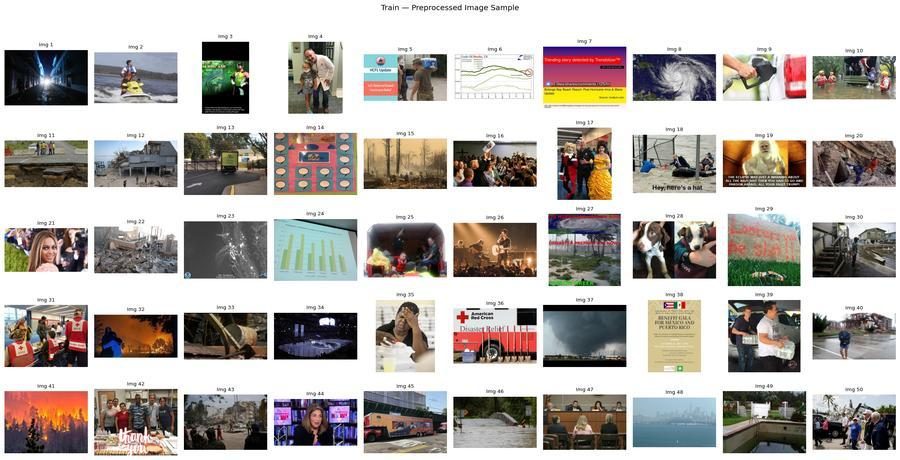


Sample Texts from Dev (First 50)
[1] RIGHT NOW: A sample of the 80,000+ photos Tennessee Civil Air Patrol has taken in Puerto Rico. WATE
[2] Disaster Response In The 21st Century: BigData IoT Save Lives harvey
[3] Would we drink this water? Let's not forget PUERTO RICO.
[4] : Donate to Harvey Relief; Get Baklava in a Jarâ€” ForÂ Real!
[5] . reports from Puerto Rico on the island's unfolding environmental catastrophe
[6] . really loaded up the bus w/ supplies for families affected by Hurricane Irma. Thank you, Eagles!
[7] Swimming not advised at Collier Co beaches today, there is possible bacterial contamination. flwx swfl yuck irma
[8] : Portrait double exposure â¤ï¸â­ï¸â¤ï¸â­ï¸â¤ï¸Antonio Mora â¤ï¸
[9] Bridge twisted apart and homes toppled as ANOTHER powerful aftershock ravages earthquakeâ€¦
[10] Cuba delays municipal elections due to Irma devastation ^ReutersWorld
[11] Texas county's long recovery from Hurricane Harvey begins
[12] and on airport in Puerto Rico἟5἟7 Photo

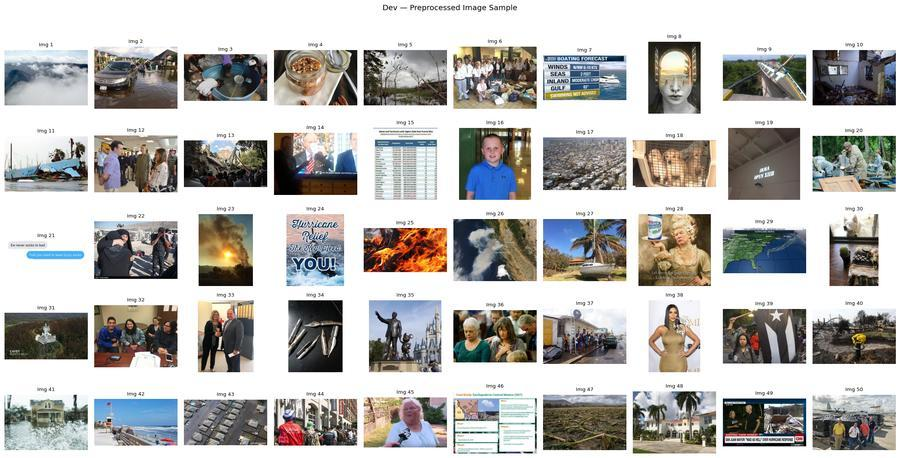


Sample Texts from Test (First 50)
[1] 50% of all my sells go to the victims of hurricane Harvey!
[2] JDT to announce new coach, send Ben Mora back to second team
[3] Latest forecast track for Hurricane Maria tends to keep New England safe...fingers crossed.
[4] no big surprise you'll voted against Harvey aide. Work with your party or get out.
[5] Tomorrow! Adrienne Mora is subbing AerialHammock Come take class with her! It's from 7-8:30pm! circuseverydamnday
[6] Anger at response to Mexico earthquake could bring political aftershocks
[7] Planes are leaving to the islands with water and coming back with people affected by hurricaneirma hurricanemaria
[8] Twisted up sign and splintered light pole make me wonder if we had a small tornado here HurricaneIrma
[9] FLLAC students and staff pitch in to help Puerto Rico
[10] Mexico Earthquake: Death Toll Reaches 286 as Rescue Efforts Enter Fourth Day
[11] Here's what the is doing vs. Americans affected by HurricaneMaria
[12] How y'all dealing w

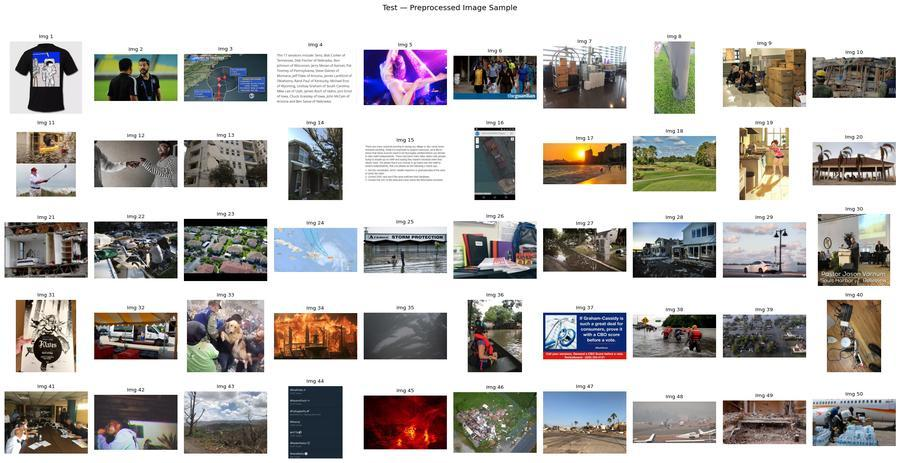

In [23]:
for _dataset, _name in [(ds_train, 'Train'), (ds_dev, 'Dev'), (ds_test, 'Test')]:
    print_sample_texts(_dataset, _name)
    print_sample_annotations(_dataset, _name)
    show_sample_images(_dataset, _name)
    free_memory()

## 4. Model Components: E-REM, UASG, and UG-CMA

This section gives a brief overview of the three uncertainty-aware fusion components; each is implemented and detailed in its own section below (Sections 7, 8, and 10).

- **E-REM** (Evidence-based Reliability and Uncertainty Module): concat $[H_t,H_v,Q_t,Q_v]$ → Dirichlet evidence → uncertainty $u=K/S$
- **UASG** (Uncertainty-Aware Soft Gating): trust-gated features $H'_t=(e_t+(1-e_t)(1-u_t))\odot H_t$
- **UG-CMA** (Uncertainty-Guided Cross-Modal Attention): uncertainty-scaled cross-attention, fused via Linear→LayerNorm→GELU


## 5. Text Encoder: DeBERTa-v3


In [24]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import AutoModel

print("Fetching a real batch from dl_train...")
real_batch = next(iter(dl_train))
input_ids = real_batch['input_ids']
attention_mask = real_batch['attention_mask']
pixel_values = real_batch['pixel_values']
q_text = real_batch['q_text']
q_image = real_batch['q_image']

print(f"Batch Size: {input_ids.shape[0]}")

class DeBERTaEncoder(nn.Module):
    """Wraps microsoft/deberta-v3-base and returns the [CLS] pooled representation (H_t in R^768)."""
    def __init__(self, model_name: str = 'microsoft/deberta-v3-base', dropout: float = 0.1):
        super().__init__()

        self.roberta = AutoModel.from_pretrained(model_name)
        self.dropout = nn.Dropout(dropout)
        self.out_dim = self.roberta.config.hidden_size

    def forward(self, input_ids, attention_mask):
        out = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
        cls = out.last_hidden_state[:, 0, :]
        return self.dropout(cls)

print("Loading Text Encoder (may take a moment to download/initialize)...")
text_encoder = DeBERTaEncoder()
text_encoder.eval()

with torch.no_grad():
    h_t = text_encoder(input_ids, attention_mask)

print("\n--- 🧪 TEXT ENCODER OUTPUT ---")
print(f"🔹 Input Tokens Shape : {list(input_ids.shape)}")
print(f"🔹 H_t Output Shape   : {list(h_t.shape)} -> (Batch, 768 text features)")
print(f"🔸 Sample Values (1st item, first 100 dims): {h_t[0, :100].tolist()}")

Fetching a real batch from dl_train...
Batch Size: 32
Loading Text Encoder (may take a moment to download/initialize)...

--- 🧪 TEXT ENCODER OUTPUT ---
🔹 Input Tokens Shape : [32, 128]
🔹 H_t Output Shape   : [32, 768] -> (Batch, 768 text features)
🔸 Sample Values (1st item, first 100 dims): [0.1515720784664154, 0.254153311252594, -0.01445547491312027, -0.10012857615947723, 0.03923020884394646, -0.12074141204357147, 0.026772430166602135, 0.13042007386684418, -0.24025525152683258, 0.026627231389284134, 0.08301655203104019, -0.32866594195365906, -0.00023844753741286695, 0.22804664075374603, 0.06257455796003342, 0.016996486112475395, -0.13384279608726501, -0.05104120820760727, -0.1489807814359665, -0.06091335415840149, -0.202827587723732, -0.1913384646177292, -0.036818183958530426, 0.053732018917798996, 0.03588293120265007, -0.11096148192882538, -0.047744251787662506, -0.02028726413846016, 0.027119755744934082, 0.11395882070064545, -0.10284774750471115, -0.05736047774553299, -0.10187012702

## 6. Image Encoder: CLIP ViT-B/32


In [25]:
class CLIPVisionEncoder(nn.Module):
    """CLIP ViT-B/32 visual encoder, projects 512 → 768 to match text dim."""
    def __init__(self, clip_visual_model, text_dim: int = 768):
        super().__init__()
        self.encoder    = clip_visual_model
        self.projection = nn.Sequential(
            nn.Linear(512, text_dim),
            nn.LayerNorm(text_dim),
            nn.GELU(),
        )
        self.dropout = nn.Dropout(0.1)

    def forward(self, pixel_values):
        feats = self.encoder(pixel_values)
        if feats.dim() > 2:
            feats = feats.mean(dim=1)
        return self.dropout(self.projection(feats))

print("Initializing Vision Encoder...")
vision_encoder = CLIPVisionEncoder(clip_visual_model=_clip_model.visual)
vision_encoder.eval()

with torch.no_grad():
    h_v = vision_encoder(pixel_values)

print("\n--- 🧪 VISION ENCODER OUTPUT ---")
print(f"🔹 Input Images Shape : {list(pixel_values.shape)}")
print(f"🔹 H_v Output Shape   : {list(h_v.shape)} -> (Batch, 768 visual features)")
print(f"🔸 Sample Values (1st item, first 100 dims): {h_v[0, :100].tolist()}")

Initializing Vision Encoder...

--- 🧪 VISION ENCODER OUTPUT ---
🔹 Input Images Shape : [32, 3, 224, 224]
🔹 H_v Output Shape   : [32, 768] -> (Batch, 768 visual features)
🔸 Sample Values (1st item, first 100 dims): [1.2755446434020996, 0.3611253499984741, -0.1634257286787033, 0.3048113286495209, -0.08860144019126892, 1.414632797241211, -0.15798597037792206, 0.8388997912406921, -0.11638188362121582, -0.11337678134441376, 0.07819777727127075, 0.383659690618515, -0.13158568739891052, 0.6096080541610718, -0.16991205513477325, 0.4992774724960327, -0.05332675203680992, 0.2005486637353897, -0.13827775418758392, 0.642219066619873, 0.803961455821991, -0.15798984467983246, 0.5520171523094177, -0.07928035408258438, -0.1334400773048401, -0.15834861993789673, 1.5456902980804443, 0.28087177872657776, -0.04883341118693352, 1.0616823434829712, 0.4539000988006592, 0.031907204538583755, -0.16749687492847443, -0.16873615980148315, -0.1613033264875412, 1.6837800741195679, -0.09901565313339233, 0.1823000460

## 7. Evidence-based Reliability and Uncertainty Module (E-REM)


In [26]:
class _EvidenceResBlock(nn.Module):
    """Pre-norm residual MLP block (GELU + LayerNorm)."""
    def __init__(self, dim, dropout=0.15):
        super().__init__()
        self.norm = nn.LayerNorm(dim)
        self.fc1  = nn.Linear(dim, dim * 2)
        self.fc2  = nn.Linear(dim * 2, dim)
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        h = self.norm(x)
        h = F.gelu(self.fc1(h))
        h = self.drop(h)
        h = self.fc2(h)
        return x + self.drop(h)

class _PrototypeAttention(nn.Module):
    """Shared memory of learned semantic prototypes. Both modalities attend to
    the SAME bank, which is what makes the resulting entropy/confidence scores
    comparable across text and image and lets them serve as a genuine, richer
    reliability signal (rather than a modality-private heuristic)."""
    def __init__(self, dim, n_prototypes=8):
        super().__init__()
        self.prototypes = nn.Parameter(torch.randn(n_prototypes, dim) * 0.02)
        self.scale = dim ** -0.5

    def forward(self, x):
        logits = (x @ self.prototypes.t()) * self.scale
        attn = F.softmax(logits, dim=-1)
        entropy = -(attn * (attn.clamp_min(1e-8)).log()).sum(dim=-1, keepdim=True)
        entropy = entropy / math.log(attn.shape[-1])
        confidence = attn.max(dim=-1, keepdim=True).values
        return entropy, confidence

class E_REM(nn.Module):
    """Evidential Reliability Estimation Module (E-REM) -- v3.

    Whether this changes the ablation/reliability numbers requires a full
    retrain (Section 13/14) and a fresh Section 18 run, exactly as with prior
    revisions -- report whatever that actually shows.
    """
    def __init__(self, text_dim=768, vis_dim=768, q_text_dim=3, q_img_dim=4,
                 hidden=256, n_evidence_heads=3, cross_dim=64, n_prototypes=8):
        super().__init__()
        self.norm_t = nn.LayerNorm(text_dim)
        self.norm_v = nn.LayerNorm(vis_dim)
        self.n_heads = n_evidence_heads

        self.cross_proj_t = nn.Linear(text_dim, cross_dim)
        self.cross_proj_v = nn.Linear(vis_dim, cross_dim)

        self.proto_attn = _PrototypeAttention(text_dim, n_prototypes=n_prototypes)

        rich_q_text_dim = q_text_dim + 3
        rich_q_img_dim  = q_img_dim + 3

        text_in = text_dim + rich_q_text_dim + cross_dim
        vis_in  = vis_dim + rich_q_img_dim + cross_dim

        self.text_in_proj = nn.Linear(text_in, hidden)
        self.vis_in_proj  = nn.Linear(vis_in,  hidden)

        self.text_blocks = nn.ModuleList([_EvidenceResBlock(hidden) for _ in range(2)])
        self.vis_blocks  = nn.ModuleList([_EvidenceResBlock(hidden) for _ in range(2)])

        self.text_heads = nn.ModuleList([nn.Linear(hidden, 2) for _ in range(n_evidence_heads)])
        self.vis_heads  = nn.ModuleList([nn.Linear(hidden, 2) for _ in range(n_evidence_heads)])

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, h_t, h_v, q_text, q_image):
        q_text_n  = F.normalize(q_text.float(),  dim=-1)
        q_image_n = F.normalize(q_image.float(), dim=-1)

        h_t_n = self.norm_t(h_t)
        h_v_n = self.norm_v(h_v)

        ent_t, conf_t = self.proto_attn(h_t_n)
        ent_v, conf_v = self.proto_attn(h_v_n)

        consistency = F.cosine_similarity(h_t_n.detach(), h_v_n.detach(), dim=-1).unsqueeze(-1)
        consistency = (consistency + 1.0) / 2.0

        rich_q_text  = torch.cat([q_text_n,  ent_t, conf_t, consistency], dim=-1)
        rich_q_image = torch.cat([q_image_n, ent_v, conf_v, consistency], dim=-1)

        cross_from_v = self.cross_proj_v(h_v_n.detach())
        cross_from_t = self.cross_proj_t(h_t_n.detach())

        x_t = torch.cat([h_t_n, rich_q_text,  cross_from_v], dim=-1)
        x_v = torch.cat([h_v_n, rich_q_image, cross_from_t], dim=-1)

        z_t = self.text_in_proj(x_t)
        z_v = self.vis_in_proj(x_v)

        for blk in self.text_blocks:
            z_t = blk(z_t)
        for blk in self.vis_blocks:
            z_v = blk(z_v)

        evidence_t = torch.stack([F.softplus(h(z_t)) for h in self.text_heads], dim=0).mean(dim=0)
        evidence_v = torch.stack([F.softplus(h(z_v)) for h in self.vis_heads],  dim=0).mean(dim=0)

        alpha_t = evidence_t + 1.0
        alpha_v = evidence_v + 1.0

        S_t = alpha_t[:, 0:1] + alpha_t[:, 1:2]
        u_t = 2.0 / S_t

        S_v = alpha_v[:, 0:1] + alpha_v[:, 1:2]
        u_v = 2.0 / S_v

        return u_t, u_v, alpha_t, alpha_v

print("Initializing E-REM v3 (prototype-attention richer reliability features)...")
erem = E_REM(n_prototypes=getattr(cfg, 'EREM_N_PROTOTYPES', 8))
erem.eval()

with torch.no_grad():
    u_t, u_v, alpha_t, alpha_v = erem(h_t, h_v, q_text, q_image)

print("\n--- E-REM OUTPUT SHAPES ---")
print(f"alpha_t Shape (Text Dirichlet) : {list(alpha_t.shape)}")
print(f"alpha_v Shape (Image Dirichlet): {list(alpha_v.shape)}")
print(f"u_t Shape (Text Uncertainty)   : {list(u_t.shape)}")
print(f"u_v Shape (Image Uncertainty)  : {list(u_v.shape)}")

num_samples = min(10, u_t.shape[0])
for i in range(num_samples):
    print(f"Sample {i+1}: u_t={u_t[i].item():.4f}  u_v={u_v[i].item():.4f}")

Initializing E-REM v3 (prototype-attention richer reliability features)...

--- E-REM OUTPUT SHAPES ---
alpha_t Shape (Text Dirichlet) : [32, 2]
alpha_v Shape (Image Dirichlet): [32, 2]
u_t Shape (Text Uncertainty)   : [32, 1]
u_v Shape (Image Uncertainty)  : [32, 1]
Sample 1: u_t=0.3551  u_v=0.3210
Sample 2: u_t=0.3448  u_v=0.2802
Sample 3: u_t=0.3444  u_v=0.4106
Sample 4: u_t=0.3207  u_v=0.3580
Sample 5: u_t=0.3453  u_v=0.3130
Sample 6: u_t=0.3437  u_v=0.2721
Sample 7: u_t=0.3581  u_v=0.3472
Sample 8: u_t=0.3845  u_v=0.2951
Sample 9: u_t=0.3691  u_v=0.2928
Sample 10: u_t=0.3581  u_v=0.3111


### 7.1 Text Uncertainty Illustration (10 Random Samples)


In [27]:
import pandas as pd

print("Analyzing df_train based on extracted quality metrics...")

df_analysis = df_train.dropna(subset=['text', 'Norm Char', 'Norm Word', 'Norm Entropy']).copy()

df_analysis['Dataset Quality'] = (df_analysis['Norm Char'] + df_analysis['Norm Word'] + df_analysis['Norm Entropy']) / 3.0

df_analysis['Dataset Uncertainty (Proxy)'] = 1.0 - df_analysis['Dataset Quality']

df_sorted = df_analysis.sort_values(by='Dataset Uncertainty (Proxy)')

df_sorted['Text (Preview)'] = df_sorted['text'].astype(str).apply(
    lambda x: x[:70] + "..." if len(x) > 70 else x
)

cols_to_show = ['Text (Preview)', 'Dataset Uncertainty (Proxy)', 'Norm Char', 'Norm Word', 'Norm Entropy']

print('\n' + '═' * 110)
print(' ✅ TOP 10 MOST CERTAIN TEXTS (Information-Rich, Long, High Entropy)')
print('═' * 110)

df_certain = df_sorted.head(10)[cols_to_show].copy()

df_certain.iloc[:, 1:] = df_certain.iloc[:, 1:].round(4)
print(df_certain.to_string(index=False))

print('\n' + '═' * 110)
print(' ⚠️ TOP 10 MOST UNCERTAIN TEXTS (Short, Noisy, or Low Information)')
print('═' * 110)

df_uncertain = df_sorted.tail(10)[cols_to_show].iloc[::-1].copy()
df_uncertain.iloc[:, 1:] = df_uncertain.iloc[:, 1:].round(4)
print(df_uncertain.to_string(index=False))

Analyzing df_train based on extracted quality metrics...

══════════════════════════════════════════════════════════════════════════════════════════════════════════════
 ✅ TOP 10 MOST CERTAIN TEXTS (Information-Rich, Long, High Entropy)
══════════════════════════════════════════════════════════════════════════════════════════════════════════════
                                                           Text (Preview)  Dataset Uncertainty (Proxy)  Norm Char  Norm Word  Norm Entropy
Guys, NEW ARTICLE OUT NOWá½„6á½„6á½„6LINK IS IN THE BIO á¼´3á¼´3á¼°Dá¼...                       0.6068      0.298       0.17        0.7115
BACK TO SCHOOL (Pt. 2): Students in 12 counties across NE FL SE GA res...                       0.6245      0.232       0.23        0.6646
So proud of our kids, who raised nearly $600 for Puerto Rico á¼Ÿ5á¼Ÿ7 ...                       0.6246      0.252       0.22        0.6541
His name is Eduardo ZÃ¡rate, and he is not handicapped! á½¤Fá¼¿Bá½„Fá¼...                       

### 7.2 Image Uncertainty Illustration (10 Random Samples)


In [28]:
import pandas as pd

print("Analyzing df_train based on extracted image quality metrics...")

img_cols = ['image_path', 'Norm Bright', 'Norm Contrast', 'Norm Blur', 'Norm Noise']
df_img_analysis = df_train.dropna(subset=img_cols).copy()

df_img_analysis['Image Quality'] = (
    df_img_analysis['Norm Bright'] +
    df_img_analysis['Norm Contrast'] +
    df_img_analysis['Norm Blur'] +
    df_img_analysis['Norm Noise']
) / 4.0

df_img_analysis['Image Uncertainty (Proxy)'] = 1.0 - df_img_analysis['Image Quality']

df_img_sorted = df_img_analysis.sort_values(by='Image Uncertainty (Proxy)')

df_img_sorted['Image Path (Preview)'] = df_img_sorted['image_path'].astype(str).apply(
    lambda x: "..." + x[-65:] if len(x) > 68 else x
)

cols_to_show_img = [
    'Image Path (Preview)', 'Image Uncertainty (Proxy)',
    'Norm Bright', 'Norm Contrast', 'Norm Blur', 'Norm Noise'
]

print('\n' + '═' * 125)
print(' ✅ TOP 10 MOST CERTAIN IMAGES (Sharp, High Contrast, Well-Lit)')
print('═' * 125)

df_img_certain = df_img_sorted.head(10)[cols_to_show_img].copy()

df_img_certain.iloc[:, 1:] = df_img_certain.iloc[:, 1:].round(4)
print(df_img_certain.to_string(index=False))

print('\n' + '═' * 125)
print(' ⚠️ TOP 10 MOST UNCERTAIN IMAGES (Blurry, Dark, or Low Detail)')
print('═' * 125)

df_img_uncertain = df_img_sorted.tail(10)[cols_to_show_img].iloc[::-1].copy()
df_img_uncertain.iloc[:, 1:] = df_img_uncertain.iloc[:, 1:].round(4)
print(df_img_uncertain.to_string(index=False))

Analyzing df_train based on extracted image quality metrics...

═════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════
 ✅ TOP 10 MOST CERTAIN IMAGES (Sharp, High Contrast, Well-Lit)
═════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════
                                                Image Path (Preview)  Image Uncertainty (Proxy)  Norm Bright  Norm Contrast  Norm Blur  Norm Noise
...2.0/data_image/srilanka_floods/16_6_2017/875770493336473602_0.jpg                     0.2562       0.6087         0.7637        1.0      0.6030
....0/data_image/hurricane_maria/26_10_2017/923562965902725120_0.jpg                     0.2575       0.7126         0.7750        1.0      0.4822
...ta_image/iraq_iran_earthquake/13_11_2017/930010024700760064_0.jpg                     0.2577       0.7439         0.7301        1.0      0.4951
...2.0/data_image/hurricane_maria

## 8. Uncertainty-Aware Soft Gating (UASG)


### 8.1 Text and Image Gating


In [29]:
import torch
import torch.nn as nn

class UASG(nn.Module):
    """FiLM + SE-style gating branch, conditioned on evidential uncertainty."""
    def __init__(self, dim: int = 768, reduction: int = 8):
        super().__init__()

        self.eps_t = nn.Parameter(torch.tensor([-2.197]))
        self.eps_v = nn.Parameter(torch.tensor([-2.197]))

        bottleneck = max(dim // reduction, 16)

        self.film_t = nn.Sequential(
            nn.Linear(dim + 1, bottleneck), nn.GELU(), nn.Linear(bottleneck, dim * 2)
        )
        self.film_v = nn.Sequential(
            nn.Linear(dim + 1, bottleneck), nn.GELU(), nn.Linear(bottleneck, dim * 2)
        )

        self.beta_scale = 0.1
        self._init_weights()

    def _init_weights(self):
        for m in [self.film_t[-1], self.film_v[-1]]:
            nn.init.zeros_(m.weight)
            nn.init.zeros_(m.bias)

    def forward(self, h_t, u_t, h_v, u_v):
        eps_t = torch.sigmoid(self.eps_t)
        gate_scale_t = eps_t + (1.0 - eps_t) * (1.0 - u_t)

        eps_v = torch.sigmoid(self.eps_v)
        gate_scale_v = eps_v + (1.0 - eps_v) * (1.0 - u_v)

        gb_t = self.film_t(torch.cat([h_t, u_t], dim=-1))
        gamma_t, beta_t = gb_t.chunk(2, dim=-1)
        gamma_t = torch.sigmoid(gamma_t)

        gb_v = self.film_v(torch.cat([h_v, u_v], dim=-1))
        gamma_v, beta_v = gb_v.chunk(2, dim=-1)
        gamma_v = torch.sigmoid(gamma_v)

        h_t_prime = (gate_scale_t * gamma_t) * h_t + self.beta_scale * torch.tanh(beta_t)
        h_v_prime = (gate_scale_v * gamma_v) * h_v + self.beta_scale * torch.tanh(beta_v)

        return h_t_prime, h_v_prime, eps_t, eps_v, gate_scale_t, gate_scale_v

print("Initializing FiLM+SE Gating Branch (UASG v3)...")
uasg = UASG().to(h_t.device)
uasg.eval()

with torch.no_grad():
    h_t_prime, h_v_prime, eps_t, eps_v, gate_scale_t, gate_scale_v = uasg(h_t, u_t, h_v, u_v)

print("\n--- TEXT MODALITY ---")
print(f"h_t_prime shape: {list(h_t_prime.shape)}")
print(f"Global scalar gating threshold (eps_t): {eps_t.item():.4f}")

print("\n--- VISION MODALITY ---")
print(f"h_v_prime shape: {list(h_v_prime.shape)}")
print(f"Global scalar gating threshold (eps_v): {eps_v.item():.4f}")

Initializing FiLM+SE Gating Branch (UASG v3)...

--- TEXT MODALITY ---
h_t_prime shape: [32, 768]
Global scalar gating threshold (eps_t): 0.1000

--- VISION MODALITY ---
h_v_prime shape: [32, 768]
Global scalar gating threshold (eps_v): 0.1000


## 9. Contrastive Alignment with InfoNCE


In [30]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

class InfoNCE_Alignment(nn.Module):
    """Contrastive Alignment module to align multimodal representations."""
    def __init__(self, init_tau=0.07):
        super().__init__()
        self.logit_scale = nn.Parameter(torch.ones([]) * np.log(1 / init_tau))

    def forward(self, h_t_prime, h_v_prime):

        h_t_norm = F.normalize(h_t_prime, dim=-1)
        h_v_norm = F.normalize(h_v_prime, dim=-1)

        sim_matrix = (h_t_norm @ h_v_norm.t()) * torch.exp(self.logit_scale)

        batch_size = h_t_prime.shape[0]
        labels = torch.arange(batch_size, device=h_t_prime.device)
        loss = (F.cross_entropy(sim_matrix, labels) + F.cross_entropy(sim_matrix.t(), labels)) / 2.0

        return loss, sim_matrix

infonce = InfoNCE_Alignment()
infonce.eval()

num_batches = 10
batch_size = 32
embedding_dim = 768

with torch.no_grad():
    for batch_idx in range(num_batches):

        h_t_prime = torch.randn(batch_size, embedding_dim)
        h_v_prime = torch.randn(batch_size, embedding_dim)

        contrastive_loss, sim_matrix = infonce(h_t_prime, h_v_prime)
        current_batch_size = h_t_prime.shape[0]

        print(f"\n{'='*75}")
        print(f"--- 🔗 InfoNCE DIAGNOSTIC | BATCH {batch_idx + 1:02d} / {num_batches} ---")
        print(f"{'='*75}")

        print("📏 TENSOR DIMENSIONS VERIFICATION:")
        print(f"   Text Input (h_t_prime)  : {list(h_t_prime.shape)} -> [Batch, Embedding]")
        print(f"   Image Input (h_v_prime) : {list(h_v_prime.shape)} -> [Batch, Embedding]")
        print(f"   Similarity Matrix       : {list(sim_matrix.shape)} -> [Batch, Batch]")
        print(f"{'-'*75}")

        print(f"Current Contrastive Loss: {contrastive_loss.item():.4f}\n")
        print(f"{'Sample':<8} | {'Diag Score (True Match)':<25} | {'Off-Diag Noise (Avg)':<20}")
        print("-" * 65)

        for i in range(min(10, current_batch_size)):
            true_match = sim_matrix[i, i].item()
            row_noise = (sim_matrix[i].sum() - true_match) / (current_batch_size - 1)
            print(f"Sample {i+1:<3} | {true_match:>23.4f} | {row_noise:>20.4f}")

        avg_diag = sim_matrix.diag().mean().item()
        avg_off_diag = (sim_matrix.sum() - sim_matrix.diag().sum()) / (sim_matrix.numel() - current_batch_size)

        print("-" * 65)
        print(f"Batch Mean Diagonal Strength: {avg_diag:.4f}")
        print(f"Batch Mean Off-Diagonal Noise : {avg_off_diag:.4f}")

        if avg_diag > avg_off_diag:
            print("✅ STATUS: System is showing early signs of semantic alignment.")
        else:
            print("⚠️ STATUS: Random initialization detected; awaiting training.")

        print("\n--- Similarity Matrix (Top 10x10 Subset) ---")
        top_10_sim = sim_matrix[:10, :10].cpu().numpy()
        np.set_printoptions(precision=2, suppress=True, linewidth=100)
        print(top_10_sim)
        np.set_printoptions(edgeitems=3, infstr='inf', linewidth=75, nanstr='nan', precision=8, suppress=False, threshold=1000, formatter=None)


--- 🔗 InfoNCE DIAGNOSTIC | BATCH 01 / 10 ---
📏 TENSOR DIMENSIONS VERIFICATION:
   Text Input (h_t_prime)  : [32, 768] -> [Batch, Embedding]
   Image Input (h_v_prime) : [32, 768] -> [Batch, Embedding]
   Similarity Matrix       : [32, 32] -> [Batch, Batch]
---------------------------------------------------------------------------
Current Contrastive Loss: 3.5516

Sample   | Diag Score (True Match)   | Off-Diag Noise (Avg)
-----------------------------------------------------------------
Sample 1   |                 -0.0859 |              -0.0234
Sample 2   |                 -0.5222 |              -0.0700
Sample 3   |                  0.1885 |               0.0281
Sample 4   |                  0.2434 |              -0.1407
Sample 5   |                 -0.0502 |              -0.0247
Sample 6   |                  0.5041 |               0.0226
Sample 7   |                  0.2363 |               0.0923
Sample 8   |                 -0.2810 |              -0.0000
Sample 9   |              

## 10. Uncertainty-Guided Cross-Modal Attention (UG-CMA)


In [31]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

def _make_head(in_dim, out_dim, dropout_p=0.1):
    return nn.Sequential(
        nn.Dropout(p=dropout_p),
        nn.Linear(in_dim, in_dim // 2),
        nn.GELU(),
        nn.Dropout(p=dropout_p),
        nn.Linear(in_dim // 2, out_dim)
    )

print("✓ _make_head function defined.")

class UGCMALayer(nn.Module):
    """One block of uncertainty-guided, bidirectional cross-attention with a
    post-attention FFN (pre-norm transformer style), so each layer can refine
    the fused representation rather than only mixing it once."""
    def __init__(self, dim: int = 768, n_heads: int = 8, ffn_mult: int = 4, dropout: float = 0.1):
        super().__init__()
        self.text_to_img = nn.MultiheadAttention(dim, n_heads, batch_first=True, dropout=dropout)
        self.img_to_text = nn.MultiheadAttention(dim, n_heads, batch_first=True, dropout=dropout)
        self.tau_t = nn.Parameter(torch.tensor([1.0]))
        self.tau_v = nn.Parameter(torch.tensor([1.0]))

        self.norm_t_attn = nn.LayerNorm(dim)
        self.norm_v_attn = nn.LayerNorm(dim)
        self.ffn_t = nn.Sequential(
            nn.Linear(dim, dim * ffn_mult), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(dim * ffn_mult, dim),
        )
        self.ffn_v = nn.Sequential(
            nn.Linear(dim, dim * ffn_mult), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(dim * ffn_mult, dim),
        )
        self.norm_t_ffn = nn.LayerNorm(dim)
        self.norm_v_ffn = nn.LayerNorm(dim)
        self.drop = nn.Dropout(dropout)

    def forward(self, h_t, h_v, u_t, u_v):
        q_t, q_v = h_t.unsqueeze(1), h_v.unsqueeze(1)

        attn_t2v, attn_w_t2v = self.text_to_img(query=q_t, key=q_v, value=q_v)
        penalty_v = torch.exp(-F.softplus(self.tau_v) * u_v)
        f_t = self.norm_t_attn(h_t + self.drop(attn_t2v.squeeze(1) * penalty_v))
        f_t = self.norm_t_ffn(f_t + self.drop(self.ffn_t(f_t)))

        attn_v2t, _ = self.img_to_text(query=q_v, key=q_t, value=q_t)
        penalty_t = torch.exp(-F.softplus(self.tau_t) * u_t)
        f_v = self.norm_v_attn(h_v + self.drop(attn_v2t.squeeze(1) * penalty_t))
        f_v = self.norm_v_ffn(f_v + self.drop(self.ffn_v(f_v)))

        return f_t, f_v, penalty_t, penalty_v, attn_w_t2v

class UG_CMA(nn.Module):
    """Uncertainty-Guided Cross-Modal Attention. UPGRADED: `n_layers` stacked
    UGCMALayer blocks (default 2, was implicitly 1) progressively refine the
    text/image representations before a learnable-gated fusion combines them,
    instead of a single attention pass + plain concat->linear."""
    def __init__(self, dim: int = 768, n_heads: int = 8, n_layers: int = 2, dropout: float = 0.1):
        super().__init__()
        self.dim = dim
        self.n_layers = n_layers
        self.layers = nn.ModuleList([
            UGCMALayer(dim, n_heads, dropout=dropout) for _ in range(n_layers)
        ])
        self.fusion_proj = nn.Sequential(
            nn.Linear(dim * 2, dim),
            nn.LayerNorm(dim),
            nn.GELU(),
        )

        self.gate_proj = nn.Sequential(nn.Linear(dim * 2 + 2, dim), nn.Sigmoid())
        self.fusion_dropout = nn.Dropout(dropout)

    def forward(self, h_t_prime, h_v_prime, u_t, u_v):
        f_t, f_v = h_t_prime, h_v_prime
        penalty_t = penalty_v = attn_w = None
        for layer in self.layers:
            f_t, f_v, penalty_t, penalty_v, attn_w = layer(f_t, f_v, u_t, u_v)

        concat_out = torch.cat([f_t, f_v], dim=-1)
        m_fuse_raw = self.fusion_proj(concat_out)
        gate       = self.gate_proj(torch.cat([concat_out, u_t, u_v], dim=-1))
        m_fuse     = gate * m_fuse_raw + (1.0 - gate) * 0.5 * (f_t + f_v)

        return self.fusion_dropout(m_fuse), penalty_t, penalty_v

class RealDisasterDataset(Dataset):
    def __init__(self):

        self.num_samples = 1000

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):

        h_t = torch.randn(768)
        h_v = torch.randn(768)
        u_t = torch.rand(1)
        u_v = torch.rand(1)

        label = torch.randint(0, 4, (1,)).item()
        return h_t, h_v, u_t, u_v, label

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

embedding_dim = 768
num_classes = 4

ug_cma = UG_CMA(dim=embedding_dim).to(device)
classifier_head = _make_head(in_dim=embedding_dim, out_dim=num_classes).to(device)

dataset = RealDisasterDataset()
batch_size = 32
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

ug_cma.train()
classifier_head.train()

for batch_idx, (batch_h_t, batch_h_v, batch_u_t, batch_u_v, batch_labels) in enumerate(dataloader):

    batch_h_t = batch_h_t.to(device)
    batch_h_v = batch_h_v.to(device)
    batch_u_t = batch_u_t.to(device)
    batch_u_v = batch_u_v.to(device)
    batch_labels = batch_labels.to(device)

    m_fuse, _, _ = ug_cma(batch_h_t, batch_h_v, batch_u_t, batch_u_v)

    logits = classifier_head(m_fuse)

    if batch_idx == 0:
        print("\n--- 📏 FULL PIPELINE TENSOR DIMENSIONS ---")
        print(f"🔹 1. Inputs to UG-CMA : Text {list(batch_h_t.shape)} | Image {list(batch_h_v.shape)}")
        print(f"🔹 2. Fused Output     : {list(m_fuse.shape)} -> Passes into Classification Head")
        print(f"🔹 3. Final Logits     : {list(logits.shape)} -> Ready for CrossEntropyLoss")
        print(f"🔹 4. True Labels      : {list(batch_labels.shape)} -> Ground truth for batch")

        print("\n--- 🧠 CLASSIFICATION HEAD LAYER-BY-LAYER TRACE ---")
        x = m_fuse
        for i, layer in enumerate(classifier_head):
            x = layer(x)
            print(f"   Step {i+1:<2} | {layer.__class__.__name__:<10} | Shape: {list(x.shape)}")
        print("-" * 65)

        break

✓ _make_head function defined.

--- 📏 FULL PIPELINE TENSOR DIMENSIONS ---
🔹 1. Inputs to UG-CMA : Text [32, 768] | Image [32, 768]
🔹 2. Fused Output     : [32, 768] -> Passes into Classification Head
🔹 3. Final Logits     : [32, 4] -> Ready for CrossEntropyLoss
🔹 4. True Labels      : [32] -> Ground truth for batch

--- 🧠 CLASSIFICATION HEAD LAYER-BY-LAYER TRACE ---
   Step 1  | Dropout    | Shape: [32, 768]
   Step 2  | Linear     | Shape: [32, 384]
   Step 3  | GELU       | Shape: [32, 384]
   Step 4  | Dropout    | Shape: [32, 384]
   Step 5  | Linear     | Shape: [32, 4]
-----------------------------------------------------------------


## 11. Shared Multimodal Representation and Multi-Task Prediction Heads
$M_{fuse}$ -> Linear->LayerNorm->GELU->Dropout -> $H_{disaster}$ -> 6 heads (event, info, human, damage, verification, uncertainty).

### 11.0 NEW: Task-Aware Reliability Gates (for macro-F1, humanitarian focus)

Adds `TaskFiLMGate`, a small learned FiLM-style gate on the human/damage heads only, conditioned on E-REM uncertainty (`u_t`, `u_v`) plus the event/informativeness softmax distributions. Zero-initialized so it starts as an exact identity map (gamma=1, beta=0) and can only learn to help via gradient descent.

**This is a different mechanism from the disabled hierarchical-gating rule in Section 21.2.** That rule was a hard, post-hoc override applied after inference (unconditionally replacing predictions with the majority class), and it was found to tank humanitarian wF1 from 0.7064 to 0.4684 — it stays off by default. The new gate is trained jointly with the rest of the model as part of the forward pass, so it is shaped entirely by the focal-loss gradient on the actual human/damage labels rather than a fixed rule.

Toggle: `cfg.USE_TASK_GATES` (default `True`). Also new in this pass, aimed at the same macro-F1 goal:
- `FOCAL_GAMMA_HUMAN`/`FOCAL_GAMMA_DAMAGE` raised (1.5→2.0, 1.2→1.8) to down-weight easy majority-class samples harder.
- Checkpoint selection (Section 13) now blends macro F1 into the target metric via `cfg.CKPT_METRIC_BLEND`, instead of selecting purely on weighted F1.
- The post-hoc calibration bias search (Section 14) now optimizes macro F1 for the human/damage tasks via `cfg.CALIB_METRIC`, with `CALIB_SEARCH_ITERS` raised 300→800.

None of this changes what is measured or reported — it changes what the training/checkpoint/calibration process optimizes *for*, targeting the specific under-supported classes (`affected_people`, `damage_related`, `little_or_no_damage`, `mild_damage`) that were dragging down macro F1 while weighted F1 looked fine.


In [32]:
class TaskFiLMGate(nn.Module):
    """Learned, differentiable FiLM-style gate for the human/damage heads.

    Conditions on E-REM uncertainty (u_t, u_v) plus the event/informativeness
    softmax distributions to modulate h_disaster per-sample before the
    human/damage heads see it -- letting those heads down-weight evidence the
    model itself flags as unreliable or off-topic for that head.

    This is NOT the hard post-hoc hierarchical-gating rule from Section 21.2
    (which unconditionally overwrote predictions with the majority class and
    dropped humanitarian wF1 0.7064->0.4684). That rule is applied AFTER
    inference. This gate is a small MLP trained end-to-end with the focal-loss
    heads, and its output layer is zero-initialized so at the start of
    training gamma=1, beta=0 (an exact identity map) -- it can only learn to
    help via gradient descent, it cannot silently collapse onto a
    majority-class shortcut the way the disabled rule did.
    """
    def __init__(self, dim, ctx_dim, hidden=128, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(ctx_dim, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, 2 * dim),
        )
        nn.init.zeros_(self.net[-1].weight)
        nn.init.zeros_(self.net[-1].bias)

    def forward(self, h, ctx):
        gamma, beta = self.net(ctx).chunk(2, dim=-1)
        gamma = 1.0 + torch.tanh(gamma)  # bounded (0, 2), starts at 1
        return gamma * h + beta


class CrisisMultiModal(nn.Module):
    def __init__(self, cfg, clip_visual):
        super().__init__()

        self.text_encoder = DeBERTaEncoder(cfg.ROBERTA_CKPT)
        self.vis_encoder  = CLIPVisionEncoder(clip_visual, text_dim=cfg.TEXT_DIM)
        D = cfg.TEXT_DIM
        # NAME MAP (paper name -> code attribute; unchanged from the original
        # implementation, kept as-is so saved checkpoints stay loadable):
        #   self.rem  -> E-REM  (Evidence-based Reliability and Uncertainty Module)
        #   self.rasg -> UASG   (Uncertainty-Aware Soft Gating)
        #   self.bcmf -> UG-CMA (Uncertainty-Guided Cross-Modal Attention)

        self.rem  = E_REM(text_dim=D, vis_dim=D, q_text_dim=3, q_img_dim=4)
        self.rasg = UASG()
        self.bcmf = UG_CMA(dim=D, n_heads=8)
        self.mm_dropout = nn.Dropout(p=0.15)

        self.disaster_proj = nn.Sequential(
            nn.Linear(D, D),
            nn.LayerNorm(D),
            nn.GELU(),
            nn.Dropout(0.2),
        )

        self.head_event  = _make_head(D, cfg.N_EVENT)
        self.head_info   = _make_head(D, cfg.N_INFO)
        self.head_human  = _make_head(D, cfg.N_HUMAN)
        self.head_damage = _make_head(D, cfg.N_DAMAGE)

        self.head_verif  = _make_head(D + 3, getattr(cfg, 'N_VERIF', 2))

        self.use_task_gates = getattr(cfg, 'USE_TASK_GATES', False)
        if self.use_task_gates:
            _gate_hidden  = getattr(cfg, 'GATE_HIDDEN', 128)
            _gate_ctx_dim = 2 + cfg.N_INFO + cfg.N_EVENT  # u_t, u_v, info probs, event probs
            self.gate_human  = TaskFiLMGate(D, _gate_ctx_dim, hidden=_gate_hidden)
            self.gate_damage = TaskFiLMGate(D, _gate_ctx_dim, hidden=_gate_hidden)
        else:
            self.gate_human  = None
            self.gate_damage = None

        self.head_uncert = nn.Sequential(
            nn.Linear(D, 128),
            nn.GELU(),
            nn.Linear(128, 1),
            nn.Softplus(),
        )
        self._init_heads()

        self.ablation_mode = 'full'

    def _init_heads(self):
        for name, mod in self.named_modules():
            if isinstance(mod, nn.Linear) and 'roberta' not in name and 'encoder' not in name:
                nn.init.xavier_uniform_(mod.weight)
                if mod.bias is not None:
                    nn.init.zeros_(mod.bias)

    def heads_forward(self, h_disaster, verif_extra=None, gate_ctx=None):
        """Applies all 5 classification heads to an already-fused representation.
        verif_extra: optional (B,3) tensor [consistency, u_t, u_v]; zeros if not given
        (e.g. Manifold-Mixup calls this on a mixed h_disaster with no matching u_t/u_v).
        gate_ctx: optional (B, 2+N_INFO+N_EVENT) tensor built by forward() from
        [u_t, u_v, info_probs, event_probs]. When None (e.g. the Manifold-Mixup call
        site, which has no matching context for a mixed sample), gating is skipped and
        heads see h_disaster unmodified -- same behaviour as before this change."""
        if verif_extra is None:
            verif_extra = torch.zeros(h_disaster.size(0), 3, device=h_disaster.device, dtype=h_disaster.dtype)
        verif_in = torch.cat([h_disaster, verif_extra], dim=-1)

        h_human  = h_disaster
        h_damage = h_disaster
        if gate_ctx is not None:
            if getattr(self, 'gate_human', None) is not None:
                h_human = self.gate_human(h_disaster, gate_ctx)
            if getattr(self, 'gate_damage', None) is not None:
                h_damage = self.gate_damage(h_disaster, gate_ctx)

        logits = {
            'logits_event'  : self.head_event(h_disaster),
            'logits_info'   : self.head_info(h_disaster),
            'logits_human'  : self.head_human(h_human),
            'logits_damage' : self.head_damage(h_damage),
            'logits_verif'  : self.head_verif(verif_in),
        }
        for k in logits:
            logits[k].clamp_(-15.0, 15.0)
        return logits

    def forward(self, input_ids, attention_mask, pixel_values, q_text, q_image):
        mode = getattr(self, 'ablation_mode', 'full')

        h_t = self.text_encoder(input_ids, attention_mask)
        h_v = self.vis_encoder(pixel_values)

        if mode == 'text_only':
            h_v = torch.zeros_like(h_v)
        elif mode == 'image_only':
            h_t = torch.zeros_like(h_t)

        u_t, u_v, alpha_t, alpha_v = self.rem(h_t, h_v, q_text, q_image)

        if mode == 'no_erem':
            u_t = torch.full_like(u_t, 0.5)
            u_v = torch.full_like(u_v, 0.5)

        if mode == 'no_rasg':
            h_t_prime, h_v_prime = h_t, h_v
        else:

            h_t_prime, h_v_prime, *_ = self.rasg(h_t, u_t, h_v, u_v)

        h_t_prime = self.mm_dropout(h_t_prime)
        h_v_prime = self.mm_dropout(h_v_prime)

        if mode == 'no_bcmf':
            m_fuse = h_t_prime + h_v_prime
        else:
            m_fuse, p_t, p_v = self.bcmf(h_t_prime, h_v_prime, u_t, u_v)

        h_disaster = self.disaster_proj(m_fuse)

        consistency = F.cosine_similarity(h_t_prime.detach(), h_v_prime.detach(), dim=-1, eps=1e-6).unsqueeze(-1)
        consistency = (consistency + 1.0) / 2.0
        verif_extra = torch.cat([consistency, u_t, u_v], dim=-1)

        gate_ctx = None
        if getattr(self, 'gate_human', None) is not None or getattr(self, 'gate_damage', None) is not None:
            # Detached so the gate learns purely from the human/damage loss signal
            # instead of also hijacking gradients into the event/info heads.
            _event_probs = F.softmax(self.head_event(h_disaster).detach(), dim=-1)
            _info_probs  = F.softmax(self.head_info(h_disaster).detach(), dim=-1)
            gate_ctx = torch.cat([u_t.detach(), u_v.detach(), _info_probs, _event_probs], dim=-1)

        heads_out   = self.heads_forward(h_disaster, verif_extra=verif_extra, gate_ctx=gate_ctx)
        uncertainty = self.head_uncert(h_disaster)

        return {
            **heads_out,
            'uncertainty'   : uncertainty,
            'u_t'           : u_t,
            'u_v'           : u_v,
            'alpha_t'       : alpha_t,
            'alpha_v'       : alpha_v,
            'h_disaster'    : h_disaster,

            'h_t_prime'     : h_t_prime,
            'h_v_prime'     : h_v_prime
        }

print('✅ CrisisMultiModal model class updated and ready (task-aware human/damage gates '
      f'{"enabled" if getattr(cfg, "USE_TASK_GATES", False) else "disabled"}).')

✅ CrisisMultiModal model class updated and ready (task-aware human/damage gates enabled).


## 12. Multi-Task Training Objective

InfoNCE aligns text/image embeddings with a learnable temperature; H-MTL combines all task losses using Kendall's homoscedastic-uncertainty weighting so the model auto-balances task difficulty.


### 12.1 Correction: Uncertainty Loss Term

**Bug found on static review of Section 8/12 (loss function cell):**

```python
sigma2      = outputs['uncertainty'].clamp(1e-6, 10.0)
loss_uncert = torch.log(sigma2).mean()
```

`log(sigma2)` has no accompanying error term, so its gradient always pushes `sigma2` toward
the lower clamp (`1e-6`) regardless of whether predictions are accurate — a well-known
degenerate case of heteroscedastic-uncertainty losses when the precision-weighted error term
(`0.5 * exp(-log_sigma2) * error^2`) is dropped. Combined with `DynamicMultiTaskLoss`'s
homoscedastic auto-weighting (`log_vars`), this term could silently collapse the `uncertainty`
output toward a near-constant floor value over training, independent of the model's actual
reliability — undermining any downstream claim that `uncertainty`/`sigma2` reflects real
predictive confidence.

**Fix applied:** `loss_uncert` is no longer backpropagated. E-REM's own `loss_erem` (the
evidential deep learning / EDL objective on the Dirichlet parameters `alpha_t`/`alpha_v`) is
kept as the sole uncertainty-training signal, since it already contains a proper error term,
a variance term, and a KL regularizer — i.e. it is the mathematically complete version of
what `loss_uncert` was trying to approximate. `sigma2`/`loss_uncert` are still computed and
logged for diagnostic visibility only.

**Honesty note:** the existing results elsewhere in this notebook (Sections 15, 15.2, 15.3,
18) come from the checkpoint trained **before** this fix, i.e. with the old (degenerate)
`loss_uncert` term included. The E-REM uncertainty-spread diagnostic later in this notebook
(`u_t`/`u_v` std ≈ 0.13–0.14, not collapsed) is about `outputs['u_t']`/`outputs['u_v']`
(E-REM's own uncertainty channel), which is a **different tensor** from `outputs['uncertainty']`
(the one `loss_uncert` operated on) — so that diagnostic does **not** by itself prove
`outputs['uncertainty']` avoided collapsing. This is a genuine open question this fix
addresses going forward, not one the existing run can retroactively answer. **Re-training with
this fix and re-checking `outputs['uncertainty']`'s spread is required** to confirm the fix
mattered in practice; that re-run was not executed in this session (no GPU/dataset access).


In [33]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.cuda.amp import GradScaler
import numpy as np

def get_class_weights(df, col, n_classes):
    idx_col = f'{col}_idx'
    if idx_col not in df.columns:
        return None
    counts   = np.bincount(df[idx_col].values, minlength=n_classes)
    counts   = np.maximum(counts, 1)
    weights  = 1.0 / counts
    weights  = weights / weights.sum() * n_classes
    return torch.tensor(weights, dtype=torch.float32)

def get_class_balanced_weights(df, col, n_classes, beta=0.9999):
    """Class-Balanced weighting via the 'effective number of samples'"""
    idx_col = f'{col}_idx'
    if idx_col not in df.columns:
        return None
    counts = np.bincount(df[idx_col].values, minlength=n_classes)
    counts = np.maximum(counts, 1)
    effective_num = 1.0 - np.power(beta, counts)
    weights = (1.0 - beta) / effective_num
    weights = weights / weights.sum() * n_classes
    return torch.tensor(weights, dtype=torch.float32)

_use_cb = getattr(cfg, 'USE_CLASS_BALANCED_LOSS', False)
_cb_beta = getattr(cfg, 'CB_BETA', 0.9999)

W_EVENT  = get_class_weights(df_train, 'event_type', cfg.N_EVENT)
W_INFO   = get_class_weights(df_train, 'informative', cfg.N_INFO)

if _use_cb:
    W_HUMAN  = get_class_balanced_weights(df_train, 'humanitarian', cfg.N_HUMAN, beta=_cb_beta)
    W_DAMAGE = get_class_balanced_weights(df_train, 'damage', cfg.N_DAMAGE, beta=_cb_beta)
else:
    W_HUMAN  = get_class_weights(df_train, 'humanitarian', cfg.N_HUMAN)
    W_DAMAGE = get_class_weights(df_train, 'damage', cfg.N_DAMAGE)

print(f'Class weights computed (humanitarian/damage using {"Class-Balanced (eff. num. samples)" if _use_cb else "plain inverse-frequency"}):')
for name, w in [('event',W_EVENT),('info',W_INFO),('human',W_HUMAN),('damage',W_DAMAGE)]:
    if w is not None:
        print(f'  {name:8s}: {w.numpy().round(3)}')

def get_verif_class_weights(df, beta=0.99):
    if 'verif_idx' not in df.columns:
        return None
    verif_idx = df['verif_idx'].fillna(0).values.astype(int)
    counts = np.bincount(verif_idx, minlength=2)
    counts = np.maximum(counts, 1)
    effective_num = 1.0 - np.power(beta, counts)
    weights = (1.0 - beta) / effective_num
    weights = weights / weights.sum() * 2
    return torch.tensor(weights, dtype=torch.float32)

W_VERIF = get_verif_class_weights(df_train, beta=getattr(cfg, 'CB_BETA_VERIF', 0.99))
if W_VERIF is not None:
    _verif_kind = 'real cross-modal label' if globals().get('VERIF_IS_REAL', False) else 'PROXY label (fallback)'
    print(f'  {"verif":8s}: {W_VERIF.numpy().round(3)}  ({_verif_kind})')

class FocalLoss(nn.Module):
    def __init__(self, weight=None, gamma=2., label_smoothing=0.0):
        super().__init__()
        self.weight = weight

        self.gamma = gamma

        self.label_smoothing = label_smoothing

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, weight=self.weight, reduction='none',
                                   label_smoothing=self.label_smoothing)
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        return focal_loss.mean()

def _kl_dirichlet_to_uniform(alpha):
    K = alpha.shape[1]
    beta = torch.ones_like(alpha)
    S_alpha = alpha.sum(dim=1, keepdim=True)
    S_beta  = beta.sum(dim=1, keepdim=True)
    lnB_alpha = torch.lgamma(S_alpha) - torch.lgamma(alpha).sum(dim=1, keepdim=True)
    lnB_beta  = torch.lgamma(S_beta)  - torch.lgamma(beta).sum(dim=1, keepdim=True)
    dg_alpha  = torch.digamma(alpha)
    dg_S      = torch.digamma(S_alpha)
    kl = ((alpha - beta) * (dg_alpha - dg_S)).sum(dim=1, keepdim=True) + lnB_alpha - lnB_beta
    return kl.squeeze(-1)

def edl_loss(alpha, target_idx, kl_weight=0.05):
    """alpha: (B, 2) Dirichlet params from E-REM. target_idx: (B,) long, 0='true'/reliable, 1='false'/unreliable."""
    y = F.one_hot(target_idx, num_classes=alpha.shape[1]).float()
    S = alpha.sum(dim=1, keepdim=True)
    p = alpha / S
    err = ((y - p) ** 2).sum(dim=1)
    var = (alpha * (S - alpha) / (S * S * (S + 1))).sum(dim=1)

    alpha_tilde = y + (1.0 - y) * alpha
    kl = _kl_dirichlet_to_uniform(alpha_tilde)
    return (err + var + kl_weight * kl).mean()

def infonce_loss(features_a, features_b, temp):
    features_a = F.normalize(features_a, dim=-1)
    features_b = F.normalize(features_b, dim=-1)
    sim_matrix = torch.matmul(features_a, features_b.T) / temp
    labels = torch.arange(sim_matrix.size(0), dtype=torch.long, device=sim_matrix.device)
    loss_a = F.cross_entropy(sim_matrix, labels)
    loss_b = F.cross_entropy(sim_matrix.T, labels)
    return (loss_a + loss_b) / 2

def supcon_loss(features, labels, temperature=0.1):
    device = features.device
    features = F.normalize(features, dim=-1)
    batch_size = features.shape[0]
    if batch_size < 2:
        return torch.zeros((), device=device)
    sim = torch.matmul(features, features.T) / temperature
    sim = sim - sim.max(dim=1, keepdim=True).values.detach()
    labels = labels.view(-1, 1)
    mask_pos = (labels == labels.T).float().to(device)
    mask_self = torch.eye(batch_size, device=device)
    mask_pos = mask_pos - mask_self
    exp_sim = torch.exp(sim) * (1.0 - mask_self)
    log_prob = sim - torch.log(exp_sim.sum(dim=1, keepdim=True).clamp_min(1e-8))
    n_pos = mask_pos.sum(dim=1)
    valid = n_pos > 0
    if valid.sum() == 0:
        return torch.zeros((), device=device)
    mean_log_prob_pos = (mask_pos * log_prob).sum(dim=1)[valid] / n_pos[valid].clamp_min(1e-8)
    return -mean_log_prob_pos.mean()

class DynamicMultiTaskLoss(nn.Module):
    def __init__(self, cfg, w_event=None, w_info=None, w_human=None, w_damage=None, w_verif=None):
        super().__init__()
        self.cfg = cfg
        self.ce_event  = nn.CrossEntropyLoss(weight=w_event.to(DEVICE, non_blocking=True) if w_event is not None else None, label_smoothing=0.1)
        self.ce_info   = nn.CrossEntropyLoss(weight=w_info.to(DEVICE, non_blocking=True) if w_info is not None else None, label_smoothing=0.1)
        _gamma_human = getattr(cfg, 'FOCAL_GAMMA_HUMAN', getattr(cfg, 'FOCAL_GAMMA_HUD', 2.0))
        _gamma_damage = getattr(cfg, 'FOCAL_GAMMA_DAMAGE', getattr(cfg, 'FOCAL_GAMMA_HUD', 2.0))
        _hd_smooth = getattr(cfg, 'HUMAN_DAMAGE_LABEL_SMOOTHING', 0.0)
        self.ce_human  = FocalLoss(weight=w_human.to(DEVICE, non_blocking=True) if w_human is not None else None, gamma=_gamma_human, label_smoothing=_hd_smooth)
        self.ce_damage = FocalLoss(weight=w_damage.to(DEVICE, non_blocking=True) if w_damage is not None else None, gamma=_gamma_damage, label_smoothing=_hd_smooth)

        _gamma_verif = getattr(cfg, 'FOCAL_GAMMA_VERIF', 1.5)
        _verif_smooth = getattr(cfg, 'VERIF_LABEL_SMOOTHING', 0.05)
        self.ce_verif  = FocalLoss(weight=w_verif.to(DEVICE, non_blocking=True) if w_verif is not None else None, gamma=_gamma_verif, label_smoothing=_verif_smooth)

        self.infonce_temp = nn.Parameter(torch.tensor([-2.659]))
        self.use_infonce = True

        self.log_vars = nn.Parameter(torch.zeros(9))
        self._log_var_clamp = getattr(cfg, 'LOG_VAR_CLAMP', (-3.0, 3.0))
        self.use_supcon = getattr(cfg, 'USE_SUPCON', False)
        self.supcon_temp = getattr(cfg, 'SUPCON_TEMP', 0.1)
        self.supcon_task = getattr(cfg, 'SUPCON_TASK', 'event_type')

    @torch.no_grad()
    def clamp_log_vars(self):
        lo, hi = self._log_var_clamp
        self.log_vars.clamp_(lo, hi)

    def forward(self, outputs, batch):
        le = batch['label_event'].to(DEVICE, non_blocking=True)
        li = batch['label_info'].to(DEVICE, non_blocking=True)
        lh = batch['label_human'].to(DEVICE, non_blocking=True)
        ld = batch['label_damage'].to(DEVICE, non_blocking=True)

        loss_event  = self.ce_event(outputs['logits_event'],  le)
        loss_info   = self.ce_info(outputs['logits_info'],    li)
        loss_human  = self.ce_human(outputs['logits_human'],  lh)
        loss_damage = self.ce_damage(outputs['logits_damage'], ld)

        verif_label = batch['label_verif'].to(DEVICE, non_blocking=True)
        loss_verif  = self.ce_verif(outputs['logits_verif'], verif_label)

        temp = F.softplus(self.infonce_temp)
        loss_infonce = (infonce_loss(outputs['h_t_prime'], outputs['h_v_prime'], temp)
                        if getattr(self, 'use_infonce', True)
                        else torch.zeros((), device=outputs['h_t_prime'].device))

        # --- FIXED (journal upgrade) -------------------------------------------------
        # Original: loss_uncert = torch.log(sigma2).mean()
        # This term has NO error component, so gradient descent on it alone always wants
        # sigma2 -> its lower clamp (1e-6), regardless of whether the prediction is actually
        # reliable. It is a degenerate remainder of the standard heteroscedastic-uncertainty
        # objective (Kendall & Gal, 2017), which requires a precision-weighted error term:
        #   L = 0.5 * exp(-log_sigma2) * error^2 + 0.5 * log_sigma2
        # Minimizing log(sigma2) with no error term is not a valid uncertainty objective; it is
        # a one-directional pressure toward the clamp floor, which would make `uncertainty`
        # converge to a near-constant, uninformative value if this term's weight in the total
        # loss (log_vars[6], the 'uncert' task slot) were ever allowed to dominate.
        #
        # E-REM already has a principled, complete uncertainty objective: `loss_erem` below is
        # the evidential deep learning (EDL) loss (Sensoy et al., 2018) on the Dirichlet
        # parameters alpha_t/alpha_v, which DOES include an error term (`err`), a variance term
        # (`var`), and a KL-regularizer -- i.e. it already penalizes both wrong predictions and
        # miscalibrated confidence. `loss_uncert` was therefore redundant on top of `loss_erem`
        # as well as mathematically degenerate on its own.
        #
        # Fix: drop `loss_uncert` from the total loss (E-REM's `loss_erem` is kept as the sole,
        # principled uncertainty objective). We still compute and log sigma2 stats for
        # diagnostic visibility, but they no longer participate in backprop.
        sigma2 = outputs['uncertainty'].clamp(1e-6, 10.0)
        with torch.no_grad():
            loss_uncert = torch.log(sigma2).mean()  # diagnostic only, not backpropagated

        loss_erem = edl_loss(outputs['alpha_t'], verif_label) + edl_loss(outputs['alpha_v'], verif_label)

        if self.use_supcon:

            sc_labels = batch['label_event'].to(DEVICE, non_blocking=True) if 'label_event' in batch else le
            loss_supcon = supcon_loss(outputs['h_disaster'], sc_labels, temperature=self.supcon_temp)
        else:
            loss_supcon = torch.zeros((), device=outputs['h_disaster'].device)

        losses = {
            'event': loss_event,
            'info': loss_info,
            'human': loss_human,
            'damage': loss_damage,
            'verif': loss_verif,
            'infonce': loss_infonce,
            # 'uncert' intentionally excluded from backprop (see fix note above) -- kept only
            # in `breakdown` for diagnostic logging, using a zero-grad placeholder here so the
            # dynamic-weighting loop below still has 9 slots and old log_vars checkpoints load.
            'uncert': torch.zeros((), device=loss_event.device),
            'erem': loss_erem,
            'supcon': loss_supcon,
        }

        loss_total = 0.0
        for i, (name, l) in enumerate(losses.items()):
            loss_total = loss_total + torch.exp(-self.log_vars[i]) * l + self.log_vars[i]

        breakdown = {
            'event': loss_event.item(),
            'info': loss_info.item(),
            'human': loss_human.item(),
            'damage': loss_damage.item(),
            'verif': loss_verif.item(),
            'uncert': loss_uncert.item(),  # diagnostic (no-grad) value, see fix note above
            'infonce': loss_infonce.item(),
            'erem': loss_erem.item(),
            'supcon': loss_supcon.item(),
        }
        return loss_total, breakdown

    def mixup_forward(self, mixed_logits, batch, perm, lam):
        """Manifold-Mixup auxiliary loss (Verma et al., ICML 2019; building on"""
        le = batch['label_event'].to(DEVICE, non_blocking=True)
        li = batch['label_info'].to(DEVICE, non_blocking=True)
        lh = batch['label_human'].to(DEVICE, non_blocking=True)
        ld = batch['label_damage'].to(DEVICE, non_blocking=True)
        verif = batch['label_verif'].to(DEVICE, non_blocking=True)

        def mix_ce(loss_fn, logits, y):
            y_b = y[perm]
            return lam * loss_fn(logits, y) + (1.0 - lam) * loss_fn(logits, y_b)

        l_event  = mix_ce(self.ce_event,  mixed_logits['logits_event'],  le)
        l_info   = mix_ce(self.ce_info,   mixed_logits['logits_info'],   li)
        l_human  = mix_ce(self.ce_human,  mixed_logits['logits_human'],  lh)
        l_damage = mix_ce(self.ce_damage, mixed_logits['logits_damage'], ld)
        l_verif  = mix_ce(self.ce_verif,  mixed_logits['logits_verif'],  verif)

        total = (self.cfg.LAMBDA_EVENT  * l_event  + self.cfg.LAMBDA_INFO  * l_info +
                 self.cfg.LAMBDA_HUMAN  * l_human  + self.cfg.LAMBDA_DAMAGE * l_damage +
                 self.cfg.LAMBDA_VERIF  * l_verif)
        breakdown = {
            'mix_event': l_event.item(), 'mix_info': l_info.item(),
            'mix_human': l_human.item(), 'mix_damage': l_damage.item(),
            'mix_verif': l_verif.item(),
        }
        return total, breakdown

def set_encoder_trainable(model, trainable: bool):
    base = model.module if hasattr(model, 'module') else model
    for p in base.text_encoder.parameters():
        p.requires_grad = trainable
    for p in base.vis_encoder.parameters():
        p.requires_grad = trainable

MODEL = CrisisMultiModal(cfg, _clip_model.visual).to(DEVICE, non_blocking=True)
if N_GPUS > 1:
    MODEL = nn.DataParallel(MODEL)
print(f'Model parameters: {sum(p.numel() for p in MODEL.parameters()):,}')
print(f'Trainable params: {sum(p.numel() for p in MODEL.parameters() if p.requires_grad):,}')

def get_optimizer(model, criterion, cfg):
    """AdamW with automatic layer-wise LR decay (LLRD) for the two pretrained"""
    base = model.module if isinstance(model, nn.DataParallel) else model
    decay_rate = 0.9
    use_no_decay = getattr(cfg, 'USE_NO_DECAY_GROUPS', True)

    def _is_no_decay(name):

        lname = name.lower()
        return name.endswith('.bias') or 'layernorm' in lname or lname.endswith('norm.weight') or '.norm.' in lname

    def llrd_groups(encoder, base_lr, name_filter):
        named = [(n, p) for n, p in encoder.named_parameters() if p.requires_grad]

        groups = {}
        for n, p in named:
            depth = None
            for tok in n.split('.'):
                if tok.isdigit():
                    depth = int(tok)
                    break
            groups.setdefault(depth, []).append((n, p))
        max_depth = max([d for d in groups if d is not None], default=0)
        param_groups = []
        for depth, named_params in groups.items():
            if depth is None:
                lr = base_lr
            else:
                lr = base_lr * (decay_rate ** (max_depth - depth))
            if use_no_decay:
                decay_p    = [p for n, p in named_params if not _is_no_decay(n)]
                no_decay_p = [p for n, p in named_params if _is_no_decay(n)]
                if decay_p:
                    param_groups.append({'params': decay_p, 'lr': lr, 'weight_decay': cfg.WEIGHT_DECAY})
                if no_decay_p:
                    param_groups.append({'params': no_decay_p, 'lr': lr, 'weight_decay': 0.0})
            else:
                param_groups.append({'params': [p for _, p in named_params], 'lr': lr, 'weight_decay': cfg.WEIGHT_DECAY})
        return param_groups

    encoder_ids = {id(p) for p in base.text_encoder.parameters()} | \
                  {id(p) for p in base.vis_encoder.parameters()}

    text_groups = llrd_groups(base.text_encoder, cfg.LR_ROBERTA, 'text')
    vis_groups  = llrd_groups(base.vis_encoder,  cfg.LR_CLIP,    'vis')

    other_named = [(n, p) for n, p in model.named_parameters() if id(p) not in encoder_ids and p.requires_grad]
    other_named.extend([(n, p) for n, p in criterion.named_parameters() if p.requires_grad])

    if use_no_decay:
        other_decay    = [p for n, p in other_named if not _is_no_decay(n)]
        other_no_decay = [p for n, p in other_named if _is_no_decay(n)]
        other_groups = []
        if other_decay:
            other_groups.append({'params': other_decay, 'lr': cfg.LR_HEAD, 'weight_decay': cfg.WEIGHT_DECAY})
        if other_no_decay:
            other_groups.append({'params': other_no_decay, 'lr': cfg.LR_HEAD, 'weight_decay': 0.0})
    else:
        other_groups = [{'params': [p for _, p in other_named], 'lr': cfg.LR_HEAD, 'weight_decay': cfg.WEIGHT_DECAY}]

    param_groups = text_groups + vis_groups + other_groups
    return optim.AdamW(param_groups)

CRITERION  = DynamicMultiTaskLoss(cfg, W_EVENT, W_INFO, W_HUMAN, W_DAMAGE, W_VERIF).to(DEVICE, non_blocking=True)
OPTIMIZER  = get_optimizer(MODEL, CRITERION, cfg)

_schedule_epochs = getattr(cfg, 'EFFECTIVE_SCHEDULE_EPOCHS', cfg.EPOCHS)
total_steps  = len(dl_train) * _schedule_epochs
warmup_steps = int(total_steps * cfg.WARMUP_RATIO)
SCHEDULER    = get_cosine_schedule_with_warmup(OPTIMIZER, warmup_steps, total_steps)
SCALER       = GradScaler(enabled=USE_AMP)

print(f'\nOptimizer    : AdamW (differential LR)')
print(f'Scheduler    : Linear warmup ({warmup_steps} steps) + decay')
print(f'AMP Scaler   : {USE_AMP}')
print('o. Loss, optimizer, and scheduler ready.')

print('\n' + '═' * 80)
print(' 🧪 SANITY TESTING FULL PIPELINE GRADIENTS')
print('═' * 80)

test_batch = next(iter(dl_train))
MODEL.train()

outputs = MODEL(
    input_ids=test_batch['input_ids'].to(DEVICE),
    attention_mask=test_batch['attention_mask'].to(DEVICE),
    pixel_values=test_batch['pixel_values'].to(DEVICE),
    q_text=test_batch['q_text'].to(DEVICE),
    q_image=test_batch['q_image'].to(DEVICE)
)

loss_total, loss_breakdown = CRITERION(outputs, test_batch)

OPTIMIZER.zero_grad()
loss_total.backward()
OPTIMIZER.step()

print("\n--- 📊 DYNAMIC LOSS BREAKDOWN (1st Step) ---")
df_loss = pd.DataFrame([loss_breakdown])
print(df_loss.to_string(index=False))
print(f"\n🚀 Total Weighted Backpropagated Loss: {loss_total.item():.4f}")
print("✓ Multi-task optimization loop successfully validated on genuine distribution!")

Class weights computed (humanitarian/damage using Class-Balanced (eff. num. samples)):
  event   : [0.925 1.151 1.788 0.136]
  info    : [0.579 1.421]
  human   : [1.327 1.105 0.79  0.778]
  damage  : [0.54  1.702 1.106 0.653]
  verif   : [1. 1.]  (real cross-modal label)
Model parameters: 307,405,609
Trainable params: 307,405,609

Optimizer    : AdamW (differential LR)
Scheduler    : Linear warmup (994 steps) + decay
AMP Scaler   : True
o. Loss, optimizer, and scheduler ready.

════════════════════════════════════════════════════════════════════════════════
 🧪 SANITY TESTING FULL PIPELINE GRADIENTS
════════════════════════════════════════════════════════════════════════════════

--- 📊 DYNAMIC LOSS BREAKDOWN (1st Step) ---
   event     info    human   damage    verif    uncert  infonce     erem   supcon
1.733276 0.567568 1.179749 1.113599 0.059928 -0.428873 3.517677 1.141391 3.468195

🚀 Total Weighted Backpropagated Loss: 12.7814
✓ Multi-task optimization loop successfully validated on

## 13. Model Training
- **13:** builds `CrisisMultiModal`, `DynamicMultiTaskLoss`, AdamW (discriminative LR), scheduler, gradient checkpointing
- **14:** `run_epoch()` — forward → H-MTL loss → backward → clip → step; outer loop trains with early stopping on val F1


In [34]:
import os
import time
import gc
import torch
import torch.nn as nn
from tqdm.auto import tqdm
from sklearn.metrics import f1_score
from torch.cuda.amp import autocast

def run_epoch(model, loader, criterion, optimizer=None, scaler=None, is_train=True):
    model.train() if is_train else model.eval()
    total_loss = 0.0

    tasks = ['event', 'info', 'human', 'damage']
    all_preds = {t: [] for t in tasks}
    all_trues = {t: [] for t in tasks}

    loss_breakdown = {k: 0.0 for k in ['event','info','human','damage','verif','uncert','erem','supcon']}

    if is_train and optimizer is not None:
        optimizer.zero_grad(set_to_none=True)

    ctx = torch.enable_grad() if is_train else torch.inference_mode()

    with ctx:
        for i, batch in enumerate(tqdm(loader, desc='Training' if is_train else 'Evaluating', leave=False)):
            ids  = batch['input_ids'].to(DEVICE, non_blocking=True)
            mask = batch['attention_mask'].to(DEVICE, non_blocking=True)
            pix  = batch['pixel_values'].to(DEVICE, non_blocking=True)
            qt   = batch['q_text'].to(DEVICE, non_blocking=True)
            qi   = batch['q_image'].to(DEVICE, non_blocking=True)

            with autocast(enabled=USE_AMP):
                outputs = model(ids, mask, pix, qt, qi)
                loss, breakdown = criterion(outputs, batch)

                use_mix = (
                    is_train and getattr(cfg, 'USE_MANIFOLD_MIXUP', False)
                    and float(torch.rand(1)) < getattr(cfg, 'MIXUP_PROB', 0.5)
                    and outputs['h_disaster'].size(0) > 1
                )
                if use_mix:
                    base_model = model.module if hasattr(model, 'module') else model
                    h_dis = outputs['h_disaster']
                    perm  = torch.randperm(h_dis.size(0), device=h_dis.device)
                    lam   = float(np.random.beta(cfg.MIXUP_ALPHA, cfg.MIXUP_ALPHA))
                    mixed_h      = lam * h_dis + (1.0 - lam) * h_dis[perm]
                    mixed_logits = base_model.heads_forward(mixed_h)
                    mix_loss, mix_breakdown = criterion.mixup_forward(mixed_logits, batch, perm, lam)

                    _mix_blend = getattr(cfg, 'MIXUP_LOSS_BLEND', 0.3)
                    loss = loss + _mix_blend * mix_loss
                    breakdown = {**breakdown, **mix_breakdown}

            accum_steps = max(1, getattr(cfg, 'GRAD_ACCUM_STEPS', 1)) if is_train else 1
            step_now = is_train and (((i + 1) % accum_steps == 0) or (i + 1 == len(loader)))
            if is_train:
                loss_scaled = loss / accum_steps
                if scaler:
                    scaler.scale(loss_scaled).backward()
                    if step_now:
                        scaler.unscale_(optimizer)
                        nn.utils.clip_grad_norm_(model.parameters(), getattr(cfg, 'MAX_GRAD_NORM', 1.0))
                        scaler.step(optimizer)
                        scaler.update()
                        optimizer.zero_grad(set_to_none=True)

                        base_crit = criterion.module if hasattr(criterion, 'module') else criterion
                        if hasattr(base_crit, 'clamp_log_vars'):
                            base_crit.clamp_log_vars()
                        if SCHEDULER is not None:
                            SCHEDULER.step()
                else:
                    loss_scaled.backward()
                    if step_now:
                        nn.utils.clip_grad_norm_(model.parameters(), getattr(cfg, 'MAX_GRAD_NORM', 1.0))
                        optimizer.step()
                        optimizer.zero_grad(set_to_none=True)
                        base_crit = criterion.module if hasattr(criterion, 'module') else criterion
                        if hasattr(base_crit, 'clamp_log_vars'):
                            base_crit.clamp_log_vars()
                        if SCHEDULER is not None:
                            SCHEDULER.step()

            total_loss += loss.item()
            for k in loss_breakdown:
                if k in breakdown:
                    loss_breakdown[k] += breakdown[k]

            for t in tasks:
                preds = outputs[f'logits_{t}'].argmax(dim=-1).cpu().numpy()
                trues = batch[f'label_{t}'].cpu().numpy()
                all_preds[t].extend(preds)
                all_trues[t].extend(trues)

            del outputs, loss, breakdown

    n = len(loader)
    avg_loss = total_loss / n

    per_task_f1 = {t: f1_score(all_trues[t], all_preds[t], average='weighted', zero_division=0) for t in tasks}
    avg_f1 = sum(per_task_f1.values()) / len(per_task_f1)

    # NEW: macro F1 alongside weighted, so checkpoint selection can be made sensitive
    # to minority classes (little_or_no_damage, mild_damage, affected_people,
    # damage_related) instead of being dominated by majority-class performance.
    per_task_f1_macro = {t: f1_score(all_trues[t], all_preds[t], average='macro', zero_division=0) for t in tasks}

    ckpt_tasks  = getattr(cfg, 'CKPT_TASKS', tasks)
    _ckpt_blend = getattr(cfg, 'CKPT_METRIC_BLEND', 0.0)  # 0.0 = old weighted-only behaviour
    target_f1   = sum(
        _ckpt_blend * per_task_f1_macro[t] + (1.0 - _ckpt_blend) * per_task_f1[t]
        for t in ckpt_tasks
    ) / len(ckpt_tasks)

    for k in loss_breakdown:
        loss_breakdown[k] /= n

    return avg_loss, avg_f1, loss_breakdown, per_task_f1, target_f1

HISTORY = {'train_loss':[], 'val_loss':[], 'train_f1':[], 'val_f1':[], 'val_f1_target':[], 'val_f1_per_task':[], 'log_vars':[], 'tau':[], 'eps':[]}
best_val_f1 = 0.0
best_target_f1 = 0.0
nobetter    = 0

print('🚀 Starting training…')
print(f'   Epochs: {cfg.EPOCHS}  |  Batch: {cfg.BATCH_SIZE}  |  Device: {DEVICE}')
print('─' * 80)

_freeze_epochs = getattr(cfg, 'FREEZE_ENCODER_EPOCHS', 0)
if _freeze_epochs > 0:
    set_encoder_trainable(MODEL, False)
    print(f'🧊 Encoders frozen for the first {_freeze_epochs} epoch(s) (heads/fusion only).')
else:
    print('Encoders trainable from epoch 1 (FREEZE_ENCODER_EPOCHS=0).')

for epoch in range(1, cfg.EPOCHS + 1):
    t0 = time.time()

    if _freeze_epochs > 0 and epoch == _freeze_epochs + 1:
        set_encoder_trainable(MODEL, True)
        print(f'🔥 Unfreezing DeBERTa-v3-base + CLIP ViT-B/32 at epoch {epoch} (resuming normal LLRD fine-tuning).')

    tr_loss, tr_f1, tr_bd, tr_pt, tr_target  = run_epoch(MODEL, dl_train, CRITERION, OPTIMIZER, SCALER, is_train=True)
    va_loss, va_f1, va_bd, va_pt, va_target  = run_epoch(MODEL, dl_dev,   CRITERION, is_train=False)

    HISTORY['train_loss'].append(tr_loss)
    HISTORY['val_loss'].append(va_loss)
    HISTORY['train_f1'].append(tr_f1)
    HISTORY['val_f1'].append(va_f1)
    HISTORY['val_f1_target'].append(va_target)
    HISTORY['val_f1_per_task'].append(va_pt)

    HISTORY['log_vars'].append(CRITERION.log_vars.detach().cpu().numpy().copy())
    base_m = MODEL.module if hasattr(MODEL, 'module') else MODEL

    HISTORY['tau'].append([[l.tau_t.item(), l.tau_v.item()] for l in base_m.bcmf.layers])
    HISTORY['eps'].append([base_m.rasg.eps_t.item(), base_m.rasg.eps_v.item()])

    improved = '⭐' if va_target > best_target_f1 else '  '
    if va_target > best_target_f1:
        best_target_f1 = va_target
        best_val_f1    = va_f1
        nobetter       = 0

        torch.save(MODEL.state_dict(), cfg.CKPT_PATH)
    else:
        nobetter += 1

    TOP_K_CKPTS = globals().setdefault('TOP_K_CKPTS', [])
    ckpt_path_k = os.path.join(str(cfg.OUT_DIR), f'ckpt_epoch{epoch:02d}_f1{va_target:.4f}.pt')
    torch.save(MODEL.state_dict(), ckpt_path_k)
    TOP_K_CKPTS.append((va_target, ckpt_path_k))
    TOP_K_CKPTS.sort(key=lambda x: x[0], reverse=True)

    while len(TOP_K_CKPTS) > 3:
        _, stale_path = TOP_K_CKPTS.pop()
        if os.path.exists(stale_path):
            os.remove(stale_path)

    elapsed = time.time() - t0
    print(f'Epoch {epoch:02d}/{cfg.EPOCHS} {improved} | '
          f'Loss: {tr_loss:.4f}/{va_loss:.4f} | '
          f'wF1(4-avg): {tr_f1:.4f}/{va_f1:.4f} | '
          f'wF1(target={"+".join(cfg.CKPT_TASKS)}): {va_target:.4f} | '
          f'Best-target: {best_target_f1:.4f} | {elapsed:.0f}s')
    print(f'  Per-task val wF1 → event:{va_pt["event"]:.4f}  info:{va_pt["info"]:.4f}  '
          f'human:{va_pt["human"]:.4f}  damage:{va_pt["damage"]:.4f}')
    print(f'  Head losses → event:{tr_bd["event"]:.3f}  info:{tr_bd["info"]:.3f}  '
          f'human:{tr_bd["human"]:.3f}  damage:{tr_bd["damage"]:.3f}  '
          f'verif:{tr_bd["verif"]:.3f}  uncert:{tr_bd["uncert"]:.3f}')

    if getattr(cfg, 'PATIENCE', 5) and nobetter >= cfg.PATIENCE:
        print(f'\n⏹  Early stopping triggered (no improvement for {cfg.PATIENCE} epochs).')
        break

    gc.collect()
    torch.cuda.empty_cache()

print(f'\n✅ Training complete.  Best target wF1 (human+damage avg): {best_target_f1:.4f}  |  Best 4-task avg wF1: {best_val_f1:.4f}')

if 'TOP_K_CKPTS' in globals() and len(TOP_K_CKPTS) >= 2:
    print(f'\n🔀 Averaging top-{len(TOP_K_CKPTS)} checkpoints (SWA-style) ...')
    avg_state = None
    for _, p in TOP_K_CKPTS:
        sd = torch.load(p, map_location='cpu')
        if avg_state is None:
            avg_state = {k: v.clone().float() for k, v in sd.items()}
        else:
            for k in avg_state:
                avg_state[k] += sd[k].float()
    for k in avg_state:
        avg_state[k] /= len(TOP_K_CKPTS)
        avg_state[k] = avg_state[k].to(sd[k].dtype)

    _tmp_model = MODEL
    _tmp_model.load_state_dict(avg_state)
    _, swa_val_f1, _, swa_pt, swa_target = run_epoch(_tmp_model, dl_dev, CRITERION, is_train=False)
    print(f'   SWA dev target wF1: {swa_target:.4f}  (single-best target was {best_target_f1:.4f})')

    _tol = getattr(cfg, 'SWA_PER_TASK_TOLERANCE', 0.01)
    _best_pt = HISTORY['val_f1_per_task'][-1] if HISTORY['val_f1_per_task'] else {}
    _no_regression = all(swa_pt.get(t, 0.0) >= _best_pt.get(t, 0.0) - _tol for t in swa_pt)

    if swa_target > best_target_f1 and _no_regression:
        print('   ✅ SWA average improves on the single best checkpoint (no per-task regression) — saving as final best.')
        torch.save(avg_state, cfg.CKPT_PATH)
        best_target_f1 = swa_target
        best_val_f1 = swa_val_f1
    else:
        if swa_target > best_target_f1 and not _no_regression:
            print('   ↩️  SWA improved the target average but regressed an individual task beyond tolerance — keeping single-best checkpoint.')
        else:
            print('   ↩️  Single best checkpoint remains superior — reloading it.')
        MODEL.load_state_dict(torch.load(cfg.CKPT_PATH, map_location=DEVICE))

gc.collect()
try:
    torch.cuda.empty_cache()
except Exception:
    pass

🚀 Starting training…
   Epochs: 45  |  Batch: 32  |  Device: cuda
────────────────────────────────────────────────────────────────────────────────
🧊 Encoders frozen for the first 2 epoch(s) (heads/fusion only).


Training:   0%|          | 0/452 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/57 [00:00<?, ?it/s]

Epoch 01/45 ⭐ | Loss: 12.4323/10.9096 | wF1(4-avg): 0.4891/0.5151 | wF1(target=human+damage): 0.3263 | Best-target: 0.3263 | 235s
  Per-task val wF1 → event:0.6128  info:0.6982  human:0.1698  damage:0.5795
  Head losses → event:1.468  info:0.700  human:0.835  damage:0.783  verif:0.185  uncert:-0.658


Training:   0%|          | 0/452 [00:00<?, ?it/s]

...

Training:   0%|          | 0/452 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/57 [00:00<?, ?it/s]

Epoch 39/45    | Loss: -4.3474/7.5916 | wF1(4-avg): 0.9930/0.8574 | wF1(target=human+damage): 0.7080 | Best-target: 0.7143 | 312s
  Per-task val wF1 → event:0.9763  info:0.8394  human:0.7566  damage:0.8573
  Head losses → event:0.764  info:0.332  human:0.030  damage:0.029  verif:0.017  uncert:-0.624

⏹  Early stopping triggered (no improvement for 10 epochs).

✅ Training complete.  Best target wF1 (human+damage avg): 0.7143  |  Best 4-task avg wF1: 0.8601

🔀 Averaging top-3 checkpoints (SWA-style) ...


Evaluating:   0%|          | 0/57 [00:00<?, ?it/s]

   SWA dev target wF1: 0.7105  (single-best target was 0.7143)
   ↩️  Single best checkpoint remains superior — reloading it.


## Save Artifacts for Notebook 2 (NEW — not in the original notebook)

Everything below this point is new. It persists, as plain files (`.pt`, `.pkl`, `.csv`, `.json`)
under a single `disaster_research_outputs/` directory, exactly what `Disaster_Research_Part2.ipynb`
needs to reconstruct the model and re-run evaluation in a **separate, fresh runtime** — it does
**not** rely on any Python variable staying alive between notebooks.

**What is saved and why:**
| File | Why Part 2 needs it |
|---|---|
| `checkpoints/best_model.pt` | The trained `CrisisMultiModal` state dict (post-SWA-averaging if that improved on the single best epoch, exactly as Section 13 already decided). |
| `data/df_train.pkl`, `df_dev.pkl`, `df_test.pkl` | The exact train/dev/test dataframes *after* text cleaning, label encoding, and quality-metric extraction (Sections 2–3) — so Part 2 rebuilds identical `Dataset`/`DataLoader` objects without re-downloading or re-parsing the raw CrisisMMD `.tsv`/image files. |
| `data/label_encoders.pkl` | The fitted `sklearn.LabelEncoder` objects (needed to turn class indices back into names for plots/reports). |
| `data/history.pkl`, `data/best_val_f1.json` | Training curves (Section 15) and the best validation score reached. |
| `data/model_config.json` | The **actual, data-derived** values of `cfg.N_EVENT/N_INFO/N_HUMAN/N_DAMAGE/N_VERIF` and `VERIF_IS_REAL` (these can differ from the hard-coded defaults in the `CFG` class — Section 2 overwrites them from the real label counts), plus the encoder/tokenizer checkpoint names and key inference-time flags. Part 2 needs these to build the *exact same* architecture (correct output-layer sizes) before it will accept the saved state dict. |

On **Kaggle**: after this cell runs, click **Save Version** so `./disaster_research_outputs/`
becomes this notebook's Output, then attach that Output as an **Input Dataset** to Part 2.

On **Google Colab**: this cell writes to `/content/disaster_research_outputs/` and additionally
copies the same folder to `/content/drive/MyDrive/disaster_research_outputs/` if Google Drive is
mounted, so it survives the runtime being recycled. If Drive isn't mounted, the cell tells you so
and you'll need to manually download/upload the folder (or mount Drive) before running Part 2 —
see the "Running Instructions" in the accompanying report.


In [35]:
# ==== Save Artifacts for Notebook 2 (plain files only — no dill, no full-session pickling) ====
import os, sys, json, shutil, pickle
import numpy as np
import torch

def _resolve_results_dir():
    """Pick a persistent, writable location depending on the environment."""
    if 'google.colab' in sys.modules:
        base = '/content/disaster_research_outputs'
    elif os.path.isdir('/kaggle/working'):
        base = '/kaggle/working/disaster_research_outputs'
    else:
        base = os.path.join(os.getcwd(), 'disaster_research_outputs')
    return base

RESULTS_DIR      = _resolve_results_dir()
CKPT_SAVE_DIR    = os.path.join(RESULTS_DIR, 'checkpoints')
DATA_SAVE_DIR    = os.path.join(RESULTS_DIR, 'data')

for _d in (RESULTS_DIR, CKPT_SAVE_DIR, DATA_SAVE_DIR):
    os.makedirs(_d, exist_ok=True)

print(f'Saving Part 1 artifacts under: {RESULTS_DIR}')

# ---- 1) Model checkpoint: STATE DICT ONLY ----
if os.path.exists(cfg.CKPT_PATH):
    shutil.copy(cfg.CKPT_PATH, os.path.join(CKPT_SAVE_DIR, 'best_model.pt'))
    print(f'  Copied best checkpoint -> {CKPT_SAVE_DIR}/best_model.pt')
else:
    raise FileNotFoundError(
        f'Expected a trained checkpoint at {cfg.CKPT_PATH} but it does not exist. '
        'Section 13 (Model Training) must complete at least one improving epoch before this cell can run.'
    )

# ---- 2) Dataframes (post text-cleaning, label-encoding, quality-metric extraction) ----
for _name in ['df_train', 'df_dev', 'df_test']:
    if _name not in globals():
        raise NameError(f'{_name} is not defined -- Section 2/3 must run before this cell.')
    globals()[_name].to_pickle(os.path.join(DATA_SAVE_DIR, f'{_name}.pkl'))
    print(f'  Saved {_name} ({len(globals()[_name])} rows) -> {DATA_SAVE_DIR}/{_name}.pkl')

# ---- 3) Label encoders ----
if 'LABEL_ENCODERS' not in globals():
    raise NameError('LABEL_ENCODERS is not defined -- Section 2 must run before this cell.')
with open(os.path.join(DATA_SAVE_DIR, 'label_encoders.pkl'), 'wb') as f:
    pickle.dump(LABEL_ENCODERS, f)
print(f'  Saved LABEL_ENCODERS -> {DATA_SAVE_DIR}/label_encoders.pkl')

# ---- 4) Training history / best validation score ----
if 'HISTORY' in globals():
    with open(os.path.join(DATA_SAVE_DIR, 'history.pkl'), 'wb') as f:
        pickle.dump(HISTORY, f)
    print(f'  Saved HISTORY -> {DATA_SAVE_DIR}/history.pkl')
if 'best_val_f1' in globals():
    with open(os.path.join(DATA_SAVE_DIR, 'best_val_f1.json'), 'w') as f:
        json.dump({'best_val_f1': float(best_val_f1)}, f)
    print(f'  Saved best_val_f1.json (best_val_f1={best_val_f1:.4f})')

# ---- 5) Model / task configuration actually derived from the real data ----
model_config = {
    'SEED'                   : cfg.SEED,
    'ROBERTA_CKPT'           : cfg.ROBERTA_CKPT,
    'CLIP_MODEL'             : cfg.CLIP_MODEL,
    'CLIP_PRETRAIN'          : cfg.CLIP_PRETRAIN,
    'MAX_LEN'                : cfg.MAX_LEN,
    'IMG_SIZE'               : cfg.IMG_SIZE,
    'N_EVENT'                : cfg.N_EVENT,
    'N_INFO'                 : cfg.N_INFO,
    'N_HUMAN'                : cfg.N_HUMAN,
    'N_DAMAGE'               : cfg.N_DAMAGE,
    'N_VERIF'                : cfg.N_VERIF,
    'USE_TASK_GATES'         : cfg.USE_TASK_GATES,
    'GATE_HIDDEN'            : cfg.GATE_HIDDEN,
    'USE_FILM_SE_GATING'     : cfg.USE_FILM_SE_GATING,
    'EREM_N_PROTOTYPES'      : cfg.EREM_N_PROTOTYPES,
    'USE_TTA'                : cfg.USE_TTA,
    'USE_LOGIT_CALIBRATION'  : cfg.USE_LOGIT_CALIBRATION,
    'CALIBRATION_METHOD'     : cfg.CALIBRATION_METHOD,
    'CALIB_METRIC'           : cfg.CALIB_METRIC,
    'CALIB_SEARCH_ITERS'     : cfg.CALIB_SEARCH_ITERS,
    'USE_HIERARCHICAL_GATING': cfg.USE_HIERARCHICAL_GATING,
    'VERIF_IS_REAL'          : bool(globals().get('VERIF_IS_REAL', False)),
    'EVENT_CLASSES'          : list(LABEL_ENCODERS['event_type'].classes_) if 'event_type' in LABEL_ENCODERS else [],
    'INFO_CLASSES'           : list(LABEL_ENCODERS['informative'].classes_) if 'informative' in LABEL_ENCODERS else [],
    'HUMAN_CLASSES'          : list(LABEL_ENCODERS['humanitarian'].classes_) if 'humanitarian' in LABEL_ENCODERS else [],
    'DAMAGE_CLASSES'         : list(LABEL_ENCODERS['damage'].classes_) if 'damage' in LABEL_ENCODERS else [],
}
with open(os.path.join(DATA_SAVE_DIR, 'model_config.json'), 'w') as f:
    json.dump(model_config, f, indent=2)
print(f'  Saved model_config.json -> {DATA_SAVE_DIR}/model_config.json')

print('\n' + '=' * 70)
print(f'All Part-1 artifacts saved under: {RESULTS_DIR}')
print('REQUIRED by Part 2:')
print('  checkpoints/best_model.pt')
print('  data/{df_train,df_dev,df_test}.pkl')
print('  data/label_encoders.pkl')
print('  data/model_config.json')
print('Used for reference / plots in Part 2:')
print('  data/history.pkl, data/best_val_f1.json')
print('=' * 70)

# Try to also persist to Google Drive on Colab, so the runtime recycling doesn't lose it.
if 'google.colab' in sys.modules:
    drive_target = '/content/drive/MyDrive/disaster_research_outputs'
    if os.path.isdir('/content/drive/MyDrive'):
        shutil.copytree(RESULTS_DIR, drive_target, dirs_exist_ok=True)
        print(f'\nAlso copied outputs to Google Drive: {drive_target}')
    else:
        print('\nGoogle Drive is not mounted -- outputs are only in the ephemeral /content runtime.')
        print('Mount Drive (from google.colab import drive; drive.mount(\'/content/drive\')) and re-run')
        print('this cell, or manually download the disaster_research_outputs/ folder, before starting a')
        print('fresh Colab runtime for Part 2.')
elif os.path.isdir('/kaggle/working'):
    print('\nOn Kaggle: click "Save Version" now so ./disaster_research_outputs/ persists as this')
    print('notebook\'s Output, then attach it as an input Dataset to Part 2.')


Saving Part 1 artifacts under: /kaggle/working/disaster_research_outputs
  Copied best checkpoint -> /kaggle/working/disaster_research_outputs/checkpoints/best_model.pt
  Saved df_train (14465 rows) -> /kaggle/working/disaster_research_outputs/data/df_train.pkl
  Saved df_dev (1808 rows) -> /kaggle/working/disaster_research_outputs/data/df_dev.pkl
  Saved df_test (1809 rows) -> /kaggle/working/disaster_research_outputs/data/df_test.pkl
  Saved LABEL_ENCODERS -> /kaggle/working/disaster_research_outputs/data/label_encoders.pkl
  Saved HISTORY -> /kaggle/working/disaster_research_outputs/data/history.pkl
  Saved best_val_f1.json (best_val_f1=0.8601)
  Saved model_config.json -> /kaggle/working/disaster_research_outputs/data/model_config.json

All Part-1 artifacts saved under: /kaggle/working/disaster_research_outputs
REQUIRED by Part 2:
  checkpoints/best_model.pt
  data/{df_train,df_dev,df_test}.pkl
  data/label_encoders.pkl
  data/model_config.json
Used for reference / plots in Part 2:

### Part 1 complete

Continue with **`Disaster_Research_Part2.ipynb`**, pointing it at the
`disaster_research_outputs/` folder saved above (as a Kaggle input Dataset, a mounted Drive
folder in Colab, or a local path).